<a href="https://colab.research.google.com/github/sarajohn-web/Obstacle-Avoiding-Micro-Robot/blob/main/30__Main_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

# Check top-level BiometricProject folder
base = '/content/drive/MyDrive/BiometricProject'
print("BASE exists:", os.path.exists(base))
if os.path.exists(base):
    print("Contents of BASE:")
    for item in os.listdir(base):
        print(" ", repr(item))

BASE exists: True
Contents of BASE:
  'FVC2004'
  'Nir face'
  'processed'
  'quality_reports'
  'edgeface_nir_finetuned.pt'


In [ ]:
import os

base = '/content/drive/MyDrive/BiometricProject'
print("BASE exists:", os.path.exists(base))
print("Is directory:", os.path.isdir(base))

if os.path.exists(base):
    contents = os.listdir(base)
    print(f"Number of items: {len(contents)}")
    for item in contents:
        print(" -", repr(item))
else:
    print("Path doesn't exist. Listing MyDrive root instead:")
    for item in os.listdir('/content/drive/MyDrive'):
        print(" -", repr(item))

BASE exists: True
Is directory: True
Number of items: 5
 - 'FVC2004'
 - 'Nir face'
 - 'processed'
 - 'quality_reports'
 - 'edgeface_nir_finetuned.pt'


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE    = '/content/drive/MyDrive/BiometricProject'
NIR_DIR = f'{BASE}/Nir face/NIR_face_dataset'
FVC_DIR = f'{BASE}/FVC2004/FVC2004/Dbs'
OUT_DIR = f'{BASE}/quality_reports'
os.makedirs(OUT_DIR, exist_ok=True)

print("NIR_DIR exists:", os.path.exists(NIR_DIR))
print("FVC_DIR exists:", os.path.exists(FVC_DIR))

# ── FACE QUALITY: Laplacian sharpness + mean pixel intensity ─────────────────
def face_quality_metrics(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return {
        'sharpness': cv2.Laplacian(img, cv2.CV_64F).var(),
        'mean_intensity': float(np.mean(img)),
    }

# ── FINGERPRINT QUALITY: ridge-to-valley ratio + coverage area ───────────────
def ridge_valley_ratio(img, block_size=16):
    h, w = img.shape
    ratios = []
    for y in range(0, h - block_size, block_size):
        for x in range(0, w - block_size, block_size):
            block = img[y:y+block_size, x:x+block_size].astype(np.float64)
            if block.std() < 1e-6:
                continue
            sorted_pix = np.sort(block.flatten())
            n = len(sorted_pix)
            valley_mean = sorted_pix[int(0.7*n):].mean()
            ridge_mean  = sorted_pix[:int(0.3*n)].mean()
            if ridge_mean > 1e-6:
                ratios.append(valley_mean / ridge_mean)
    return float(np.mean(ratios)) if ratios else 0.0

def fp_quality_metrics(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coverage = float(np.sum(otsu > 0) / otsu.size)
    rv_ratio = ridge_valley_ratio(img)
    return {'ridge_valley_ratio': rv_ratio, 'coverage': coverage}

# ── SCAN FACE DATASET ──────────────────────────────────────────────────────
face_rows = []
face_files = [f for f in os.listdir(NIR_DIR) if f.lower().endswith('.bmp')]
print(f"Found {len(face_files)} NIR face images")

for fname in face_files:
    person_id = fname.split('-')[0]
    metrics = face_quality_metrics(os.path.join(NIR_DIR, fname))
    if metrics is None:
        continue
    metrics.update({'filename': fname, 'person_id': person_id,
                     'path': os.path.join(NIR_DIR, fname)})
    face_rows.append(metrics)

face_df = pd.DataFrame(face_rows)
print(f"Readable face images: {len(face_df)}")

# ── SCAN FINGERPRINT DATASET ───────────────────────────────────────────────
fp_rows = []
db_folders = ['DB1_A', 'DB1_B', 'DB2_A', 'DB2_B', 'DB3_A', 'DB3_B', 'DB4_A', 'DB4_B']

for db in db_folders:
    db_path = os.path.join(FVC_DIR, db)
    if not os.path.exists(db_path):
        continue
    files = [f for f in os.listdir(db_path) if f.lower().endswith(('.tif', '.bmp', '.png', '.jpg'))]
    for fname in files:
        person_id = f"{db}_{fname.split('_')[0]}"
        metrics = fp_quality_metrics(os.path.join(db_path, fname))
        if metrics is None:
            continue
        metrics.update({'filename': fname, 'person_id': person_id, 'db': db,
                         'path': os.path.join(db_path, fname)})
        fp_rows.append(metrics)

fp_df = pd.DataFrame(fp_rows)
print(f"Readable fingerprint images: {len(fp_df)}")

# ── DATA-DRIVEN THRESHOLDS ─────────────────────────────────────────────────
LOWER_PCT = 10

face_thresh = {
    'sharpness_min':      np.percentile(face_df['sharpness'],      LOWER_PCT),
    'mean_intensity_min': np.percentile(face_df['mean_intensity'], 5),
    'mean_intensity_max': np.percentile(face_df['mean_intensity'], 95),
}
face_df['pass'] = (
    (face_df['sharpness']      >= face_thresh['sharpness_min']) &
    (face_df['mean_intensity'] >= face_thresh['mean_intensity_min']) &
    (face_df['mean_intensity'] <= face_thresh['mean_intensity_max'])
)
print("FACE thresholds:", {k: round(v, 2) for k, v in face_thresh.items()})
print(f"Pass: {face_df['pass'].sum()} / {len(face_df)} ({face_df['pass'].mean()*100:.1f}%)")

fp_thresh = {
    'rv_ratio_min': np.percentile(fp_df['ridge_valley_ratio'], LOWER_PCT),
    'coverage_min': np.percentile(fp_df['coverage'], LOWER_PCT),
}
fp_df['pass'] = (
    (fp_df['ridge_valley_ratio'] >= fp_thresh['rv_ratio_min']) &
    (fp_df['coverage']           >= fp_thresh['coverage_min'])
)
print("\nFINGERPRINT thresholds:", {k: round(v, 4) for k, v in fp_thresh.items()})
print(f"Pass: {fp_df['pass'].sum()} / {len(fp_df)} ({fp_df['pass'].mean()*100:.1f}%)")

# ── PER-PERSON SURVIVAL CHECK ──────────────────────────────────────────────
face_person_survival = face_df.groupby('person_id')['pass'].sum()
fp_person_survival   = fp_df.groupby('person_id')['pass'].sum()

print(f"\nFace persons with 0 surviving images : {(face_person_survival == 0).sum()} / {len(face_person_survival)}")
print(f"Face persons with <2 surviving images: {(face_person_survival < 2).sum()} / {len(face_person_survival)}")
print(f"FP persons with 0 surviving images   : {(fp_person_survival == 0).sum()} / {len(fp_person_survival)}")
print(f"FP persons with <2 surviving images  : {(fp_person_survival < 2).sum()} / {len(fp_person_survival)}")

# ── SAVE ─────────────────────────────────────────────────────────────────────
face_df.to_csv(f'{OUT_DIR}/quality_report_face.csv', index=False)
fp_df.to_csv(f'{OUT_DIR}/quality_report_fp.csv', index=False)
face_df[face_df['pass']].to_csv(f'{OUT_DIR}/quality_passed_face.csv', index=False)
fp_df[fp_df['pass']].to_csv(f'{OUT_DIR}/quality_passed_fp.csv', index=False)

print("\nSaved quality_passed_face.csv and quality_passed_fp.csv — these feed Step 2.")

NIR_DIR exists: True
FVC_DIR exists: True
Found 0 NIR face images
Readable face images: 0


KeyboardInterrupt: 

In [ ]:
import os

NIR_DIR = '/content/drive/MyDrive/BiometricProject/Nir face/NIR_face_dataset'
FVC_DIR = '/content/drive/MyDrive/BiometricProject/FVC2004/FVC2004/Dbs'

print("--- NIR_DIR contents (first 20) ---")
nir_contents = os.listdir(NIR_DIR)
print(f"Total items: {len(nir_contents)}")
print(nir_contents[:20])

print("\n--- File extensions found in NIR_DIR ---")
exts = set(os.path.splitext(f)[1].lower() for f in nir_contents)
print(exts)

print("\n--- Is it files or subfolders? ---")
for item in nir_contents[:5]:
    full = os.path.join(NIR_DIR, item)
    print(item, "-> DIR" if os.path.isdir(full) else "-> FILE")

--- NIR_DIR contents (first 20) ---
Total items: 1
['NIR_face_dataset']

--- File extensions found in NIR_DIR ---
{''}

--- Is it files or subfolders? ---
NIR_face_dataset -> DIR


In [ ]:
NIR_DIR = '/content/drive/MyDrive/BiometricProject/Nir face/NIR_face_dataset/NIR_face_dataset'
print("NIR_DIR exists:", os.path.exists(NIR_DIR))
print(os.listdir(NIR_DIR)[:20])

NIR_DIR exists: True
['0158-19-a.bmp', '0157-46-a.bmp', '0157-01-a.bmp', '0156-13-a.bmp', '0155-00-a.bmp', '0153-06-a.bmp', '0154-11-a.bmp', '0152-12-a.bmp', '0151-25-a.bmp', '0152-00-a.bmp', '0151-07-a.bmp', '0154-19-a.bmp', '0158-01-a.bmp', '0153-34-a.bmp', '0153-25-a.bmp', '0151-44-a.bmp', '0154-20-a.bmp', '0154-17-a-g.bmp', '0157-05-a.bmp', '0155-48-a.bmp']


In [ ]:
FVC_DIR = '/content/drive/MyDrive/BiometricProject/FVC2004/FVC2004/Dbs'
print("FVC_DIR exists:", os.path.exists(FVC_DIR))
if os.path.exists(FVC_DIR):
    print(os.listdir(FVC_DIR))

FVC_DIR exists: True
['index_a.MFR', 'index_a.MFA', 'index_B.MFA', 'index_B.MFR', 'DB1_A', 'DB4_B', 'DB1_B', 'DB4_A', 'DB2_B', 'DB3_B', 'DB3_A', 'DB2_A']


In [ ]:
import re
# The previous cell took a long time due to intensive image processing, especially for fingerprint quality metrics which involve block-wise analysis and sorting of pixel values for thousands of images.
nir_contents = os.listdir(NIR_DIR)
normal = [f for f in nir_contents if re.match(r'^\d{4}-\d{2}-[a-z]\.bmp$', f)]
odd    = [f for f in nir_contents if f not in normal]
print(f"Normal pattern: {len(normal)}")
print(f"Odd pattern: {len(odd)}")
print(odd[:20])

Normal pattern: 3328
Odd pattern: 629
['0154-17-a-g.bmp', '0154-10-a-g.bmp', '0154-26-a-g.bmp', '0153-26-a (1).bmp', '0159-02-a-g.bmp', '0159-13-a-g.bmp', '0154-25-a-g.bmp', '0159-23-a-g.bmp', '0159-14-a-g.bmp', '0155-05-a (1).bmp', '0159-17-a-g.bmp', '0154-05-a-g.bmp', '0159-46-a-g.bmp', '0160-14-a-g.bmp', '0160-03-a-g.bmp', '0166-16-a-g.bmp', '0166-00-a-g.bmp', '0162-41-a-g.bmp', '0160-02-a-g.bmp', '0160-24-a-g.bmp']


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

BASE    = '/content/drive/MyDrive/BiometricProject'
NIR_DIR = f'{BASE}/Nir face/NIR_face_dataset/NIR_face_dataset'
FVC_DIR = f'{BASE}/FVC2004/FVC2004/Dbs'
OUT_DIR = f'{BASE}/quality_reports'
os.makedirs(OUT_DIR, exist_ok=True)

print("NIR_DIR exists:", os.path.exists(NIR_DIR))
print("FVC_DIR exists:", os.path.exists(FVC_DIR))

# ── FACE QUALITY: Laplacian sharpness + mean pixel intensity ─────────────────
def face_quality_metrics(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return {
        'sharpness': cv2.Laplacian(img, cv2.CV_64F).var(),
        'mean_intensity': float(np.mean(img)),
    }

# ── FINGERPRINT QUALITY: ridge-to-valley ratio + coverage area ───────────────
def ridge_valley_ratio(img, block_size=16):
    h, w = img.shape
    ratios = []
    for y in range(0, h - block_size, block_size):
        for x in range(0, w - block_size, block_size):
            block = img[y:y+block_size, x:x+block_size].astype(np.float64)
            if block.std() < 1e-6:
                continue
            sorted_pix = np.sort(block.flatten())
            n = len(sorted_pix)
            valley_mean = sorted_pix[int(0.7*n):].mean()
            ridge_mean  = sorted_pix[:int(0.3*n)].mean()
            if ridge_mean > 1e-6:
                ratios.append(valley_mean / ridge_mean)
    return float(np.mean(ratios)) if ratios else 0.0

def fp_quality_metrics(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coverage = float(np.sum(otsu > 0) / otsu.size)
    rv_ratio = ridge_valley_ratio(img)
    return {'ridge_valley_ratio': rv_ratio, 'coverage': coverage}

# ── SCAN FACE DATASET ──────────────────────────────────────────────────────
face_rows = []
face_files = [f for f in os.listdir(NIR_DIR) if f.lower().endswith('.bmp')]
print(f"Found {len(face_files)} NIR face images")

for fname in face_files:
    person_id = fname.split('-')[0]
    metrics = face_quality_metrics(os.path.join(NIR_DIR, fname))
    if metrics is None:
        continue
    metrics.update({'filename': fname, 'person_id': person_id,
                     'path': os.path.join(NIR_DIR, fname)})
    face_rows.append(metrics)

face_df = pd.DataFrame(face_rows)
print(f"Readable face images: {len(face_df)}")

# ── SCAN FINGERPRINT DATASET ───────────────────────────────────────────────
fp_rows = []
db_folders = ['DB1_A', 'DB1_B', 'DB2_A', 'DB2_B', 'DB3_A', 'DB3_B', 'DB4_A', 'DB4_B']

for db in db_folders:
    db_path = os.path.join(FVC_DIR, db)
    if not os.path.exists(db_path):
        continue
    files = [f for f in os.listdir(db_path) if f.lower().endswith(('.tif', '.bmp', '.png', '.jpg'))]
    for fname in files:
        person_id = f"{db}_{fname.split('_')[0]}"
        metrics = fp_quality_metrics(os.path.join(db_path, fname))
        if metrics is None:
            continue
        metrics.update({'filename': fname, 'person_id': person_id, 'db': db,
                         'path': os.path.join(db_path, fname)})
        fp_rows.append(metrics)

fp_df = pd.DataFrame(fp_rows)
print(f"Readable fingerprint images: {len(fp_df)}")

# ── DATA-DRIVEN THRESHOLDS ─────────────────────────────────────────────────
LOWER_PCT = 10

face_thresh = {
    'sharpness_min':      np.percentile(face_df['sharpness'],      LOWER_PCT),
    'mean_intensity_min': np.percentile(face_df['mean_intensity'], 5),
    'mean_intensity_max': np.percentile(face_df['mean_intensity'], 95),
}
face_df['pass'] = (
    (face_df['sharpness']      >= face_thresh['sharpness_min']) &
    (face_df['mean_intensity'] >= face_thresh['mean_intensity_min']) &
    (face_df['mean_intensity'] <= face_thresh['mean_intensity_max'])
)
print("FACE thresholds:", {k: round(v, 2) for k, v in face_thresh.items()})
print(f"Pass: {face_df['pass'].sum()} / {len(face_df)} ({face_df['pass'].mean()*100:.1f}%)")

fp_thresh = {
    'rv_ratio_min': np.percentile(fp_df['ridge_valley_ratio'], LOWER_PCT),
    'coverage_min': np.percentile(fp_df['coverage'], LOWER_PCT),
}
fp_df['pass'] = (
    (fp_df['ridge_valley_ratio'] >= fp_thresh['rv_ratio_min']) &
    (fp_df['coverage']           >= fp_thresh['coverage_min'])
)
print("\nFINGERPRINT thresholds:", {k: round(v, 4) for k, v in fp_thresh.items()})
print(f"Pass: {fp_df['pass'].sum()} / {len(fp_df)} ({fp_df['pass'].mean()*100:.1f}%)")

# ── PER-PERSON SURVIVAL CHECK ──────────────────────────────────────────────
face_person_survival = face_df.groupby('person_id')['pass'].sum()
fp_person_survival   = fp_df.groupby('person_id')['pass'].sum()

print(f"\nFace persons with 0 surviving images : {(face_person_survival == 0).sum()} / {len(face_person_survival)}")
print(f"Face persons with <2 surviving images: {(face_person_survival < 2).sum()} / {len(face_person_survival)}")
print(f"FP persons with 0 surviving images   : {(fp_person_survival == 0).sum()} / {len(fp_person_survival)}")
print(f"FP persons with <2 surviving images  : {(fp_person_survival < 2).sum()} / {len(fp_person_survival)}")

# ── SAVE ─────────────────────────────────────────────────────────────────────
face_df.to_csv(f'{OUT_DIR}/quality_report_face.csv', index=False)
fp_df.to_csv(f'{OUT_DIR}/quality_report_fp.csv', index=False)
face_df[face_df['pass']].to_csv(f'{OUT_DIR}/quality_passed_face.csv', index=False)
fp_df[fp_df['pass']].to_csv(f'{OUT_DIR}/quality_passed_fp.csv', index=False)

print("\nSaved quality_passed_face.csv and quality_passed_fp.csv — these feed Step 2.")

NIR_DIR exists: True
FVC_DIR exists: True
Found 3957 NIR face images
Readable face images: 3957
Readable fingerprint images: 3536
FACE thresholds: {'sharpness_min': np.float64(37.74), 'mean_intensity_min': np.float64(13.58), 'mean_intensity_max': np.float64(55.26)}
Pass: 3300 / 3957 (83.4%)

FINGERPRINT thresholds: {'rv_ratio_min': np.float64(1.311), 'coverage_min': np.float64(0.1079)}
Pass: 2843 / 3536 (80.4%)

Face persons with 0 surviving images : 6 / 197
Face persons with <2 surviving images: 8 / 197
FP persons with 0 surviving images   : 1 / 440
FP persons with <2 surviving images  : 2 / 440

Saved quality_passed_face.csv and quality_passed_fp.csv — these feed Step 2.


In [ ]:
import os, sys, random, importlib.util, subprocess
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── LOAD QUALITY-PASSED FACE LIST (from Step 1) ──────────────────────────────
face_df = pd.read_csv(f'{OUT_DIR}/quality_passed_face.csv')
person_counts = face_df.groupby('person_id').size()
trainable_persons = person_counts[person_counts >= 2].index.tolist()
single_image_persons = person_counts[person_counts == 1].index.tolist()

print(f"Quality-passed face images: {len(face_df)}")
print(f"Persons usable for fine-tuning (>=2 images): {len(trainable_persons)}")
print(f"Persons with exactly 1 image (enrollment-only): {len(single_image_persons)}")

person_files = defaultdict(list)
for _, row in face_df[face_df['person_id'].isin(trainable_persons)].iterrows():
    person_files[row['person_id']].append(row['path'])

# ── CLONE / LOAD EDGEFACE ────────────────────────────────────────────────────
if not os.path.exists('/content/edgeface'):
    subprocess.run(['git', 'clone', 'https://github.com/otroshi/edgeface.git', '/content/edgeface'])
sys.path.insert(0, '/content/edgeface')

spec = importlib.util.spec_from_file_location("timmfr", "/content/edgeface/backbones/timmfr.py")
timmfr = importlib.util.module_from_spec(spec)
sys.modules["timmfr"] = timmfr
spec.loader.exec_module(timmfr)

face_model_ft = timmfr.replace_linear_with_lowrank_2(
    timmfr.get_timmfrv2('edgenext_x_small', batchnorm=False), rank_ratio=0.6)
face_model_ft.load_state_dict(torch.load(
    '/content/edgeface/checkpoints/edgeface_xs_gamma_06.pt', map_location='cpu'))
print("EdgeFace base weights loaded ✅")

# ── FREEZE ALL, UNFREEZE ONLY HEAD/CLASSIFIER (fix for overfitting) ─────────
for name, param in face_model_ft.named_parameters():
    param.requires_grad = False
for name, param in face_model_ft.named_parameters():
    if any(x in name for x in ['head', 'classifier']):
        param.requires_grad = True

trainable = sum(p.numel() for p in face_model_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in face_model_ft.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

# ── PAIR DATASET (genuine = same person, imposter = different person) ───────
class NIRFacePairDataset(Dataset):
    def __init__(self, person_files, transform=None):
        self.pairs, self.labels, self.transform = [], [], transform
        pids = list(person_files.keys())
        for pid in pids:
            imgs = person_files[pid]
            for i in range(len(imgs)):
                for j in range(i+1, min(i+4, len(imgs))):
                    self.pairs.append((imgs[i], imgs[j])); self.labels.append(1)
        n_genuine = len(self.pairs)
        for _ in range(n_genuine):
            pid1, pid2 = random.sample(pids, 2)
            img1 = random.choice(person_files[pid1])
            img2 = random.choice(person_files[pid2])
            self.pairs.append((img1, img2)); self.labels.append(0)
        print(f"NIR pairs — Genuine: {n_genuine}, Imposter: {n_genuine}, Total: {len(self.pairs)}")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img1 = Image.open(self.pairs[idx][0]).convert('RGB')
        img2 = Image.open(self.pairs[idx][1]).convert('RGB')
        if self.transform:
            img1, img2 = self.transform(img1), self.transform(img2)
        return img1, img2, torch.tensor(self.labels[idx], dtype=torch.float32)

# ── TRAIN/VAL SPLIT BY PERSON (prevents identity leakage) ────────────────────
all_pids = list(person_files.keys())
random.seed(42); random.shuffle(all_pids)
split = int(0.8 * len(all_pids))
train_pids, val_pids = all_pids[:split], all_pids[split:]
train_person_files = {p: person_files[p] for p in train_pids}
val_person_files   = {p: person_files[p] for p in val_pids}
print(f"Train persons: {len(train_pids)}, Val persons: {len(val_pids)}")

train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

random.seed(42)
train_dataset = NIRFacePairDataset(train_person_files, transform=train_transform)
val_dataset   = NIRFacePairDataset(val_person_files, transform=val_transform)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader    = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ── SIAMESE WRAPPER + CONTRASTIVE LOSS ───────────────────────────────────────
class SiameseEdgeFace(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
    def forward_once(self, x):
        return nn.functional.normalize(self.backbone(x), p=2, dim=1)
    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, e1, e2, label):
        dist = nn.functional.pairwise_distance(e1, e2)
        loss = (label * dist.pow(2) +
                (1 - label) * torch.clamp(self.margin - dist, min=0).pow(2))
        return loss.mean()

siamese   = SiameseEdgeFace(face_model_ft).to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, siamese.parameters()),
                        lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# ── TRAIN WITH EARLY STOPPING ──────────────────────────────────────────────
NUM_EPOCHS = 15
PATIENCE   = 3
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    siamese.train()
    total_train = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        e1, e2 = siamese(img1, img2)
        loss = criterion(e1, e2, label)
        loss.backward(); optimizer.step()
        total_train += loss.item()

    siamese.eval()
    total_val = 0
    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            e1, e2 = siamese(img1, img2)
            total_val += criterion(e1, e2, label).item()

    avg_train = total_train / len(train_loader)
    avg_val   = total_val / len(val_loader)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        epochs_no_improve = 0
        torch.save(siamese.backbone.state_dict(), f'{BASE}/edgeface_nir_finetuned.pt')
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | ✅ Best saved")
    else:
        epochs_no_improve += 1
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | no improvement ({epochs_no_improve}/{PATIENCE})")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping — no improvement for {PATIENCE} epochs.")
        break

    scheduler.step()

print(f"\nBest val loss: {best_val_loss:.4f}")
print(f"Model saved: {BASE}/edgeface_nir_finetuned.pt")

Device: cuda
Quality-passed face images: 3300
Persons usable for fine-tuning (>=2 images): 189
Persons with exactly 1 image (enrollment-only): 2
EdgeFace base weights loaded ✅
Trainable params: 81,856 / 1,770,492
Train persons: 151, Val persons: 38
NIR pairs — Genuine: 6986, Imposter: 6986, Total: 13972
NIR pairs — Genuine: 1776, Imposter: 1776, Total: 3552
Epoch 01 | Train: 0.1660 | Val: 0.1505 | ✅ Best saved
Epoch 02 | Train: 0.1316 | Val: 0.1347 | ✅ Best saved
Epoch 03 | Train: 0.1177 | Val: 0.1258 | ✅ Best saved
Epoch 04 | Train: 0.1099 | Val: 0.1234 | ✅ Best saved
Epoch 05 | Train: 0.1060 | Val: 0.1214 | ✅ Best saved
Epoch 06 | Train: 0.1032 | Val: 0.1190 | ✅ Best saved
Epoch 07 | Train: 0.1009 | Val: 0.1182 | ✅ Best saved
Epoch 08 | Train: 0.1000 | Val: 0.1177 | ✅ Best saved
Epoch 09 | Train: 0.0986 | Val: 0.1172 | ✅ Best saved
Epoch 10 | Train: 0.0980 | Val: 0.1166 | ✅ Best saved
Epoch 11 | Train: 0.0974 | Val: 0.1162 | ✅ Best saved
Epoch 12 | Train: 0.0972 | Val: 0.1159 | ✅ Bes

In [ ]:
import os, sys, importlib.util
import torch
import torch.nn as nn

BASE = '/content/drive/MyDrive/BiometricProject'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if not os.path.exists('/content/edgeface'):
    import subprocess
    subprocess.run(['git', 'clone', 'https://github.com/otroshi/edgeface.git', '/content/edgeface'])
sys.path.insert(0, '/content/edgeface')

spec = importlib.util.spec_from_file_location("timmfr", "/content/edgeface/backbones/timmfr.py")
timmfr = importlib.util.module_from_spec(spec)
sys.modules["timmfr"] = timmfr
spec.loader.exec_module(timmfr)

face_model_ft = timmfr.replace_linear_with_lowrank_2(
    timmfr.get_timmfrv2('edgenext_x_small', batchnorm=False), rank_ratio=0.6)
face_model_ft.load_state_dict(torch.load(f'{BASE}/edgeface_nir_finetuned.pt', map_location=device))
print("Fine-tuned EdgeFace weights loaded ✅")

class SiameseEdgeFace(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
    def forward_once(self, x):
        return nn.functional.normalize(self.backbone(x), p=2, dim=1)
    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

siamese = SiameseEdgeFace(face_model_ft).to(device)

Fine-tuned EdgeFace weights loaded ✅


In [ ]:
for name in ['siamese', 'val_loader', 'val_dataset', 'OUT_DIR']:
    print(name, "exists" if name in dir() else "MISSING")

siamese exists
val_loader MISSING
val_dataset MISSING
OUT_DIR MISSING


In [ ]:
import random
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

# ── REBUILD PERSON_FILES FROM QUALITY-PASSED CSV ─────────────────────────────
face_df = pd.read_csv(f'{OUT_DIR}/quality_passed_face.csv')
person_counts = face_df.groupby('person_id').size()
trainable_persons = person_counts[person_counts >= 2].index.tolist()

person_files = defaultdict(list)
for _, row in face_df[face_df['person_id'].isin(trainable_persons)].iterrows():
    person_files[row['person_id']].append(row['path'])

# ── SAME TRAIN/VAL SPLIT AS TRAINING (same seed = same split) ───────────────
all_pids = list(person_files.keys())
random.seed(42); random.shuffle(all_pids)
split = int(0.8 * len(all_pids))
val_pids = all_pids[split:]
val_person_files = {p: person_files[p] for p in val_pids}
print(f"Val persons: {len(val_pids)}")

# ── PAIR DATASET (same class as training) ────────────────────────────────────
class NIRFacePairDataset(Dataset):
    def __init__(self, person_files, transform=None):
        self.pairs, self.labels, self.transform = [], [], transform
        pids = list(person_files.keys())
        for pid in pids:
            imgs = person_files[pid]
            for i in range(len(imgs)):
                for j in range(i+1, min(i+4, len(imgs))):
                    self.pairs.append((imgs[i], imgs[j])); self.labels.append(1)
        n_genuine = len(self.pairs)
        for _ in range(n_genuine):
            pid1, pid2 = random.sample(pids, 2)
            img1 = random.choice(person_files[pid1])
            img2 = random.choice(person_files[pid2])
            self.pairs.append((img1, img2)); self.labels.append(0)
        print(f"NIR pairs — Genuine: {n_genuine}, Imposter: {n_genuine}, Total: {len(self.pairs)}")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img1 = Image.open(self.pairs[idx][0]).convert('RGB')
        img2 = Image.open(self.pairs[idx][1]).convert('RGB')
        if self.transform:
            img1, img2 = self.transform(img1), self.transform(img2)
        return img1, img2, torch.tensor(self.labels[idx], dtype=torch.float32)

val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

random.seed(42)
val_dataset = NIRFacePairDataset(val_person_files, transform=val_transform)
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

Val persons: 38
NIR pairs — Genuine: 1776, Imposter: 1776, Total: 3552


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

siamese.eval()

all_distances = []
all_labels = []

with torch.no_grad():
    for img1, img2, label in val_loader:
        img1, img2 = img1.to(device), img2.to(device)
        e1, e2 = siamese(img1, img2)
        dist = torch.nn.functional.pairwise_distance(e1, e2)
        all_distances.extend(dist.cpu().numpy())
        all_labels.extend(label.numpy())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)

print(f"Genuine pair distance — mean: {all_distances[all_labels==1].mean():.4f}, std: {all_distances[all_labels==1].std():.4f}")
print(f"Imposter pair distance — mean: {all_distances[all_labels==0].mean():.4f}, std: {all_distances[all_labels==0].std():.4f}")

thresholds = np.linspace(all_distances.min(), all_distances.max(), 200)
results = []

for t in thresholds:
    preds = (all_distances < t).astype(int)
    tp = np.sum((preds == 1) & (all_labels == 1))
    tn = np.sum((preds == 0) & (all_labels == 0))
    fp = np.sum((preds == 1) & (all_labels == 0))
    fn = np.sum((preds == 0) & (all_labels == 1))
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0
    acc = (tp + tn) / len(all_labels)
    f1  = f1_score(all_labels, preds, zero_division=0)
    results.append({'threshold': t, 'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1})

results_df = pd.DataFrame(results)

best_acc_row = results_df.loc[results_df['accuracy'].idxmax()]
best_f1_row  = results_df.loc[results_df['f1'].idxmax()]
eer_idx = (results_df['far'] - results_df['frr']).abs().idxmin()
eer_row = results_df.loc[eer_idx]

print("\n=== BEST ACCURACY ===")
print(f"Threshold: {best_acc_row['threshold']:.4f} | Accuracy: {best_acc_row['accuracy']*100:.2f}% | "
      f"FAR: {best_acc_row['far']*100:.2f}% | FRR: {best_acc_row['frr']*100:.2f}% | F1: {best_acc_row['f1']:.4f}")

print("\n=== BEST F1 ===")
print(f"Threshold: {best_f1_row['threshold']:.4f} | Accuracy: {best_f1_row['accuracy']*100:.2f}% | "
      f"FAR: {best_f1_row['far']*100:.2f}% | FRR: {best_f1_row['frr']*100:.2f}% | F1: {best_f1_row['f1']:.4f}")

print("\n=== EQUAL ERROR RATE (EER) POINT ===")
print(f"Threshold: {eer_row['threshold']:.4f} | Accuracy: {eer_row['accuracy']*100:.2f}% | "
      f"FAR: {eer_row['far']*100:.2f}% | FRR: {eer_row['frr']*100:.2f}% | EER: {(eer_row['far']+eer_row['frr'])/2*100:.2f}%")

results_df.to_csv(f'{OUT_DIR}/face_threshold_sweep.csv', index=False)
print(f"\nFull sweep saved to {OUT_DIR}/face_threshold_sweep.csv")

Genuine pair distance — mean: 0.3542, std: 0.1782
Imposter pair distance — mean: 0.8307, std: 0.2334

=== BEST ACCURACY ===
Threshold: 0.5292 | Accuracy: 87.02% | FAR: 10.14% | FRR: 15.82% | F1: 0.8664

=== BEST F1 ===
Threshold: 0.5992 | Accuracy: 86.37% | FAR: 17.51% | FRR: 9.74% | F1: 0.8688

=== EQUAL ERROR RATE (EER) POINT ===
Threshold: 0.5603 | Accuracy: 86.40% | FAR: 13.85% | FRR: 13.34% | EER: 13.60%

Full sweep saved to /content/drive/MyDrive/BiometricProject/quality_reports/face_threshold_sweep.csv


In [ ]:
mnet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

for param in mnet.features.parameters():
    param.requires_grad = False
for name, param in mnet.features.named_parameters():
    if name.startswith('12.'):
        param.requires_grad = True

fp_backbone = nn.Sequential(mnet.features, mnet.avgpool, nn.Flatten())
print("MobileNetV3-Small loaded, embedding dim: 576 ✅")

MobileNetV3-Small loaded, embedding dim: 576 ✅


In [ ]:
import os, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── LOAD QUALITY-PASSED FINGERPRINT LIST (from Step 1) ───────────────────────
fp_df = pd.read_csv(f'{OUT_DIR}/quality_passed_fp.csv')
person_counts = fp_df.groupby('person_id').size()
trainable_persons = person_counts[person_counts >= 2].index.tolist()
single_image_persons = person_counts[person_counts == 1].index.tolist()

print(f"Quality-passed fingerprint images: {len(fp_df)}")
print(f"Persons usable for fine-tuning (>=2 images): {len(trainable_persons)}")
print(f"Persons with exactly 1 image (enrollment-only): {len(single_image_persons)}")

person_files = defaultdict(list)
for _, row in fp_df[fp_df['person_id'].isin(trainable_persons)].iterrows():
    person_files[row['person_id']].append(row['path'])

# ── LOAD MOBILENETV3-SMALL, FREEZE BEFORE WRAPPING (this is the fix) ─────────
mnet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

for param in mnet.features.parameters():
    param.requires_grad = False
for name, param in mnet.features.named_parameters():
    if name.startswith('12.'):
        param.requires_grad = True

fp_backbone = nn.Sequential(mnet.features, mnet.avgpool, nn.Flatten())  # -> 576-D
print("MobileNetV3-Small loaded, embedding dim: 576 ✅")

trainable = sum(p.numel() for p in fp_backbone.parameters() if p.requires_grad)
total     = sum(p.numel() for p in fp_backbone.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

# ── PAIR DATASET ──────────────────────────────────────────────────────────────
class FPPairDataset(Dataset):
    def __init__(self, person_files, transform=None):
        self.pairs, self.labels, self.transform = [], [], transform
        pids = list(person_files.keys())
        for pid in pids:
            imgs = person_files[pid]
            for i in range(len(imgs)):
                for j in range(i+1, min(i+4, len(imgs))):
                    self.pairs.append((imgs[i], imgs[j])); self.labels.append(1)
        n_genuine = len(self.pairs)
        for _ in range(n_genuine):
            pid1, pid2 = random.sample(pids, 2)
            img1 = random.choice(person_files[pid1])
            img2 = random.choice(person_files[pid2])
            self.pairs.append((img1, img2)); self.labels.append(0)
        print(f"FP pairs — Genuine: {n_genuine}, Imposter: {n_genuine}, Total: {len(self.pairs)}")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img1 = Image.open(self.pairs[idx][0]).convert('RGB')
        img2 = Image.open(self.pairs[idx][1]).convert('RGB')
        if self.transform:
            img1, img2 = self.transform(img1), self.transform(img2)
        return img1, img2, torch.tensor(self.labels[idx], dtype=torch.float32)

# ── TRAIN/VAL SPLIT BY PERSON ─────────────────────────────────────────────────
all_pids = list(person_files.keys())
random.seed(42); random.shuffle(all_pids)
split = int(0.8 * len(all_pids))
train_pids, val_pids = all_pids[:split], all_pids[split:]
train_person_files = {p: person_files[p] for p in train_pids}
val_person_files   = {p: person_files[p] for p in val_pids}
print(f"Train persons: {len(train_pids)}, Val persons: {len(val_pids)}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

random.seed(42)
train_dataset = FPPairDataset(train_person_files, transform=train_transform)
val_dataset   = FPPairDataset(val_person_files, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# ── SIAMESE WRAPPER + CONTRASTIVE LOSS ───────────────────────────────────────
class SiameseFP(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
    def forward_once(self, x):
        return nn.functional.normalize(self.backbone(x), p=2, dim=1)
    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, e1, e2, label):
        dist = nn.functional.pairwise_distance(e1, e2)
        loss = (label * dist.pow(2) +
                (1 - label) * torch.clamp(self.margin - dist, min=0).pow(2))
        return loss.mean()

siamese_fp = SiameseFP(fp_backbone).to(device)
criterion  = ContrastiveLoss(margin=1.0)
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, siamese_fp.parameters()),
                         lr=5e-5, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# ── TRAIN WITH EARLY STOPPING ──────────────────────────────────────────────
NUM_EPOCHS = 15
PATIENCE   = 3
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    siamese_fp.train()
    total_train = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        e1, e2 = siamese_fp(img1, img2)
        loss = criterion(e1, e2, label)
        loss.backward(); optimizer.step()
        total_train += loss.item()

    siamese_fp.eval()
    total_val = 0
    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            e1, e2 = siamese_fp(img1, img2)
            total_val += criterion(e1, e2, label).item()

    avg_train = total_train / len(train_loader)
    avg_val   = total_val / len(val_loader)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        epochs_no_improve = 0
        torch.save(siamese_fp.backbone.state_dict(), f'{BASE}/mobilenetv3_fp_finetuned.pt')
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | ✅ Best saved")
    else:
        epochs_no_improve += 1
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | no improvement ({epochs_no_improve}/{PATIENCE})")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping — no improvement for {PATIENCE} epochs.")
        break

    scheduler.step()

print(f"\nBest val loss: {best_val_loss:.4f}")
print(f"Model saved: {BASE}/mobilenetv3_fp_finetuned.pt")

Device: cuda
Quality-passed fingerprint images: 2843
Persons usable for fine-tuning (>=2 images): 438
Persons with exactly 1 image (enrollment-only): 1
MobileNetV3-Small loaded, embedding dim: 576 ✅
Trainable params: 56,448 / 927,008
Train persons: 350, Val persons: 88
FP pairs — Genuine: 4743, Imposter: 4743, Total: 9486
FP pairs — Genuine: 1167, Imposter: 1167, Total: 2334
Epoch 01 | Train: 0.2457 | Val: 0.2250 | ✅ Best saved
Epoch 02 | Train: 0.2321 | Val: 0.2099 | ✅ Best saved
Epoch 03 | Train: 0.2196 | Val: 0.1993 | ✅ Best saved
Epoch 04 | Train: 0.2109 | Val: 0.1956 | ✅ Best saved
Epoch 05 | Train: 0.2058 | Val: 0.1912 | ✅ Best saved
Epoch 06 | Train: 0.2003 | Val: 0.1860 | ✅ Best saved
Epoch 07 | Train: 0.1964 | Val: 0.1851 | ✅ Best saved
Epoch 08 | Train: 0.1953 | Val: 0.1830 | ✅ Best saved
Epoch 09 | Train: 0.1921 | Val: 0.1804 | ✅ Best saved
Epoch 10 | Train: 0.1896 | Val: 0.1788 | ✅ Best saved
Epoch 11 | Train: 0.1887 | Val: 0.1781 | ✅ Best saved
Epoch 12 | Train: 0.1886 | V

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

siamese_fp.eval()

all_distances = []
all_labels = []

with torch.no_grad():
    for img1, img2, label in val_loader:
        img1, img2 = img1.to(device), img2.to(device)
        e1, e2 = siamese_fp(img1, img2)
        dist = torch.nn.functional.pairwise_distance(e1, e2)
        all_distances.extend(dist.cpu().numpy())
        all_labels.extend(label.numpy())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)

print(f"Genuine pair distance — mean: {all_distances[all_labels==1].mean():.4f}, std: {all_distances[all_labels==1].std():.4f}")
print(f"Imposter pair distance — mean: {all_distances[all_labels==0].mean():.4f}, std: {all_distances[all_labels==0].std():.4f}")

thresholds = np.linspace(all_distances.min(), all_distances.max(), 200)
results = []

for t in thresholds:
    preds = (all_distances < t).astype(int)
    tp = np.sum((preds == 1) & (all_labels == 1))
    tn = np.sum((preds == 0) & (all_labels == 0))
    fp = np.sum((preds == 1) & (all_labels == 0))
    fn = np.sum((preds == 0) & (all_labels == 1))
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0
    acc = (tp + tn) / len(all_labels)
    f1  = f1_score(all_labels, preds, zero_division=0)
    results.append({'threshold': t, 'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1})

results_df = pd.DataFrame(results)

best_acc_row = results_df.loc[results_df['accuracy'].idxmax()]
best_f1_row  = results_df.loc[results_df['f1'].idxmax()]
eer_idx = (results_df['far'] - results_df['frr']).abs().idxmin()
eer_row = results_df.loc[eer_idx]

print("\n=== BEST ACCURACY ===")
print(f"Threshold: {best_acc_row['threshold']:.4f} | Accuracy: {best_acc_row['accuracy']*100:.2f}% | "
      f"FAR: {best_acc_row['far']*100:.2f}% | FRR: {best_acc_row['frr']*100:.2f}% | F1: {best_acc_row['f1']:.4f}")

print("\n=== BEST F1 ===")
print(f"Threshold: {best_f1_row['threshold']:.4f} | Accuracy: {best_f1_row['accuracy']*100:.2f}% | "
      f"FAR: {best_f1_row['far']*100:.2f}% | FRR: {best_f1_row['frr']*100:.2f}% | F1: {best_f1_row['f1']:.4f}")

print("\n=== EQUAL ERROR RATE (EER) POINT ===")
print(f"Threshold: {eer_row['threshold']:.4f} | Accuracy: {eer_row['accuracy']*100:.2f}% | "
      f"FAR: {eer_row['far']*100:.2f}% | FRR: {eer_row['frr']*100:.2f}% | EER: {(eer_row['far']+eer_row['frr'])/2*100:.2f}%")

results_df.to_csv(f'{OUT_DIR}/fp_threshold_sweep.csv', index=False)
print(f"\nFull sweep saved to {OUT_DIR}/fp_threshold_sweep.csv")

Genuine pair distance — mean: 0.5562, std: 0.1162
Imposter pair distance — mean: 0.9646, std: 0.1868

=== BEST ACCURACY ===
Threshold: 0.7658 | Accuracy: 88.86% | FAR: 18.42% | FRR: 3.86% | F1: 0.8962

=== BEST F1 ===
Threshold: 0.7854 | Accuracy: 88.86% | FAR: 19.45% | FRR: 2.83% | F1: 0.8972

=== EQUAL ERROR RATE (EER) POINT ===
Threshold: 0.6807 | Accuracy: 87.23% | FAR: 12.94% | FRR: 12.60% | EER: 12.77%

Full sweep saved to /content/drive/MyDrive/BiometricProject/quality_reports/fp_threshold_sweep.csv


In [ ]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── FACE EMBEDDINGS (512-D via fine-tuned EdgeFace) ──────────────────────────
face_df = pd.read_csv(f'{OUT_DIR}/quality_passed_face.csv')

face_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

face_model_ft.eval()
face_embeddings = {}

with torch.no_grad():
    for _, row in tqdm(face_df.iterrows(), total=len(face_df), desc="Face embeddings"):
        img = Image.open(row['path']).convert('RGB')
        img_t = face_transform(img).unsqueeze(0).to(device)
        emb = torch.nn.functional.normalize(face_model_ft(img_t), p=2, dim=1)
        face_embeddings[row['filename']] = {
            'embedding': emb.cpu().numpy().flatten(),
            'person_id': row['person_id']
        }

print(f"Face embeddings extracted: {len(face_embeddings)}, dim: {list(face_embeddings.values())[0]['embedding'].shape}")
np.save(f'{OUT_DIR}/face_embeddings.npy', face_embeddings, allow_pickle=True)

# ── FINGERPRINT EMBEDDINGS (576-D via fine-tuned MobileNetV3) ────────────────
fp_df = pd.read_csv(f'{OUT_DIR}/quality_passed_fp.csv')

fp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

fp_backbone.eval()
fp_embeddings = {}

with torch.no_grad():
    for _, row in tqdm(fp_df.iterrows(), total=len(fp_df), desc="Fingerprint embeddings"):
        img = Image.open(row['path']).convert('RGB')
        img_t = fp_transform(img).unsqueeze(0).to(device)
        emb = torch.nn.functional.normalize(fp_backbone(img_t), p=2, dim=1)
        fp_embeddings[row['filename']] = {
            'embedding': emb.cpu().numpy().flatten(),
            'person_id': row['person_id']
        }

print(f"Fingerprint embeddings extracted: {len(fp_embeddings)}, dim: {list(fp_embeddings.values())[0]['embedding'].shape}")
np.save(f'{OUT_DIR}/fp_embeddings.npy', fp_embeddings, allow_pickle=True)

Face embeddings: 100%|██████████| 3300/3300 [26:41<00:00,  2.06it/s]


Face embeddings extracted: 3300, dim: (512,)


Fingerprint embeddings: 100%|██████████| 2843/2843 [00:40<00:00, 70.86it/s]


Fingerprint embeddings extracted: 892, dim: (576,)


In [ ]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── FINGERPRINT EMBEDDINGS (576-D via fine-tuned MobileNetV3) — FIXED KEY ────
fp_df = pd.read_csv(f'{OUT_DIR}/quality_passed_fp.csv')

fp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

fp_backbone.eval()
fp_embeddings = {}

with torch.no_grad():
    for _, row in tqdm(fp_df.iterrows(), total=len(fp_df), desc="Fingerprint embeddings"):
        img = Image.open(row['path']).convert('RGB')
        img_t = fp_transform(img).unsqueeze(0).to(device)
        emb = torch.nn.functional.normalize(fp_backbone(img_t), p=2, dim=1)
        fp_embeddings[row['path']] = {          # <-- key changed from filename to path
            'embedding': emb.cpu().numpy().flatten(),
            'person_id': row['person_id'],
            'filename': row['filename'],
            'db': row['db']
        }

print(f"Fingerprint embeddings extracted: {len(fp_embeddings)}, dim: {list(fp_embeddings.values())[0]['embedding'].shape}")
np.save(f'{OUT_DIR}/fp_embeddings.npy', fp_embeddings, allow_pickle=True)

Fingerprint embeddings: 100%|██████████| 2843/2843 [00:38<00:00, 74.52it/s]


Fingerprint embeddings extracted: 2843, dim: (576,)


In [ ]:
import numpy as np
import pandas as pd
import random
from sklearn.metrics import f1_score
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

# ── LOAD EMBEDDINGS ───────────────────────────────────────────────────────────
face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()

# ── GROUP EMBEDDINGS BY PERSON ────────────────────────────────────────────────
face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])

fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

# only persons with >=2 samples can form genuine pairs
face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]
print(f"Face persons (>=2 samples): {len(face_persons)}")
print(f"FP persons (>=2 samples): {len(fp_persons)}")

# ── RANDOM VIRTUAL-IDENTITY MAPPING (face_person <-> fp_person) ───────────────
random.seed(42)
random.shuffle(face_persons)
random.shuffle(fp_persons)

n_virtual = min(len(face_persons), len(fp_persons))
virtual_identities = list(zip(face_persons[:n_virtual], fp_persons[:n_virtual]))
print(f"Virtual identities created: {n_virtual}")

# ── BUILD PAIRED INSTANCES PER VIRTUAL IDENTITY ───────────────────────────────
# each "instance" = one face embedding + one fp embedding, paired index-wise
virtual_instances = defaultdict(list)   # vid -> list of (face_emb, fp_emb)
for face_p, fp_p in virtual_identities:
    f_embs = face_person_embs[face_p]
    p_embs = fp_person_embs[fp_p]
    k = min(len(f_embs), len(p_embs), 4)   # cap at 4 instances per identity
    for i in range(k):
        virtual_instances[(face_p, fp_p)].append((f_embs[i], p_embs[i]))

# ── BUILD GENUINE / IMPOSTER PAIRS OF INSTANCES ───────────────────────────────
genuine_pairs = []
vids = list(virtual_instances.keys())
for vid in vids:
    insts = virtual_instances[vid]
    for i in range(len(insts)):
        for j in range(i+1, len(insts)):
            genuine_pairs.append((insts[i], insts[j]))

n_genuine = len(genuine_pairs)
imposter_pairs = []
random.seed(42)
for _ in range(n_genuine):
    vid1, vid2 = random.sample(vids, 2)
    inst1 = random.choice(virtual_instances[vid1])
    inst2 = random.choice(virtual_instances[vid2])
    imposter_pairs.append((inst1, inst2))

print(f"Genuine multimodal pairs: {n_genuine}")
print(f"Imposter multimodal pairs: {len(imposter_pairs)}")

# ── FUSION-RATIO SWEEP ─────────────────────────────────────────────────────
def evaluate_ratio(w_face, genuine_pairs, imposter_pairs):
    w_fp = 1 - w_face
    distances, labels = [], []

    for (f1, p1), (f2, p2) in genuine_pairs:
        v1 = np.concatenate([w_face * f1, w_fp * p1])
        v2 = np.concatenate([w_face * f2, w_fp * p2])
        distances.append(np.linalg.norm(v1 - v2))
        labels.append(1)

    for (f1, p1), (f2, p2) in imposter_pairs:
        v1 = np.concatenate([w_face * f1, w_fp * p1])
        v2 = np.concatenate([w_face * f2, w_fp * p2])
        distances.append(np.linalg.norm(v1 - v2))
        labels.append(0)

    distances = np.array(distances)
    labels = np.array(labels)

    thresholds = np.linspace(distances.min(), distances.max(), 100)
    best = {'accuracy': 0}
    for t in thresholds:
        preds = (distances < t).astype(int)
        tp = np.sum((preds==1) & (labels==1)); tn = np.sum((preds==0) & (labels==0))
        fp = np.sum((preds==1) & (labels==0)); fn = np.sum((preds==0) & (labels==1))
        far = fp/(fp+tn) if (fp+tn)>0 else 0
        frr = fn/(fn+tp) if (fn+tp)>0 else 0
        acc = (tp+tn)/len(labels)
        f1s = f1_score(labels, preds, zero_division=0)
        if acc > best['accuracy']:
            best = {'threshold': t, 'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1s}

    eer_diffs = []
    for t in thresholds:
        preds = (distances < t).astype(int)
        fp = np.sum((preds==1) & (labels==0)); tn = np.sum((preds==0) & (labels==0))
        fn = np.sum((preds==0) & (labels==1)); tp = np.sum((preds==1) & (labels==1))
        far = fp/(fp+tn) if (fp+tn)>0 else 0
        frr = fn/(fn+tp) if (fn+tp)>0 else 0
        eer_diffs.append(abs(far-frr))
    eer = (thresholds[np.argmin(eer_diffs)], eer_diffs[np.argmin(eer_diffs)])

    best['eer_threshold'] = eer[0]
    return best

ratios_to_test = np.arange(0.05, 1.0, 0.05)   # 0.05, 0.10, ..., 0.95
sweep_results = []

for w_face in ratios_to_test:
    result = evaluate_ratio(w_face, genuine_pairs, imposter_pairs)
    sweep_results.append({
        'face_weight': round(w_face, 2),
        'fp_weight': round(1 - w_face, 2),
        'accuracy': result['accuracy'],
        'far': result['far'],
        'frr': result['frr'],
        'f1': result['f1'],
        'threshold': result['threshold']
    })
    print(f"Face:{w_face:.2f} / FP:{1-w_face:.2f} | Acc: {result['accuracy']*100:.2f}% | "
          f"FAR: {result['far']*100:.2f}% | FRR: {result['frr']*100:.2f}% | F1: {result['f1']:.4f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv(f'{OUT_DIR}/fusion_ratio_sweep.csv', index=False)

best_row = sweep_df.loc[sweep_df['accuracy'].idxmax()]
print(f"\n=== BEST FUSION RATIO ===")
print(f"Face weight: {best_row['face_weight']} | FP weight: {best_row['fp_weight']}")
print(f"Accuracy: {best_row['accuracy']*100:.2f}% | FAR: {best_row['far']*100:.2f}% | "
      f"FRR: {best_row['frr']*100:.2f}% | F1: {best_row['f1']:.4f}")
print(f"\nFull sweep saved to {OUT_DIR}/fusion_ratio_sweep.csv")

Face persons (>=2 samples): 189
FP persons (>=2 samples): 438
Virtual identities created: 189
Genuine multimodal pairs: 1056
Imposter multimodal pairs: 1056
Face:0.05 / FP:0.95 | Acc: 88.30% | FAR: 19.70% | FRR: 3.69% | F1: 0.8917
Face:0.10 / FP:0.90 | Acc: 88.45% | FAR: 19.60% | FRR: 3.50% | F1: 0.8931
Face:0.15 / FP:0.85 | Acc: 88.73% | FAR: 19.13% | FRR: 3.41% | F1: 0.8955
Face:0.20 / FP:0.80 | Acc: 89.11% | FAR: 16.38% | FRR: 5.40% | F1: 0.8968
Face:0.25 / FP:0.75 | Acc: 90.15% | FAR: 15.06% | FRR: 4.64% | F1: 0.9064
Face:0.30 / FP:0.70 | Acc: 91.57% | FAR: 12.22% | FRR: 4.64% | F1: 0.9188
Face:0.35 / FP:0.65 | Acc: 93.70% | FAR: 8.14% | FRR: 4.45% | F1: 0.9382
Face:0.40 / FP:0.60 | Acc: 94.70% | FAR: 7.67% | FRR: 2.94% | F1: 0.9482
Face:0.45 / FP:0.55 | Acc: 94.93% | FAR: 5.30% | FRR: 4.83% | F1: 0.9495
Face:0.50 / FP:0.50 | Acc: 95.41% | FAR: 3.60% | FRR: 5.59% | F1: 0.9536
Face:0.55 / FP:0.45 | Acc: 95.83% | FAR: 3.60% | FRR: 4.73% | F1: 0.9581
Face:0.60 / FP:0.40 | Acc: 95.41% 

In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

# ── LOAD EMBEDDINGS ───────────────────────────────────────────────────────────
face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()

# ── CONFIRMED FUSION WEIGHTS (from Step 4 sweep) ─────────────────────────────
W_FACE = 0.55
W_FP   = 0.45

FUSED_DIM = 512 + 576   # 1088
BIOHASH_BITS = 128

# ── JOHNSON-LINDENSTRAUSS RANDOM PROJECTION MATRIX ───────────────────────────
# Standard JL construction: entries ~ N(0, 1/sqrt(BIOHASH_BITS)) so the
# projection roughly preserves relative distances (JL lemma).
# CRITICAL: this matrix must be generated ONCE and reused for every enrollment
# and every verification — a different matrix per patient defeats the purpose
# (distances would no longer be comparable). Save it to disk immediately.

JL_MATRIX_PATH = f'{BASE}/jl_projection_matrix.npy'

if os.path.exists(JL_MATRIX_PATH):
    jl_matrix = np.load(JL_MATRIX_PATH)
    print(f"Loaded existing JL matrix from disk: shape {jl_matrix.shape}")
else:
    rng = np.random.RandomState(42)   # fixed seed for reproducibility
    jl_matrix = rng.normal(loc=0.0, scale=1.0/np.sqrt(BIOHASH_BITS),
                            size=(FUSED_DIM, BIOHASH_BITS))
    np.save(JL_MATRIX_PATH, jl_matrix)
    print(f"Generated NEW JL matrix, shape {jl_matrix.shape}, saved to {JL_MATRIX_PATH}")

# ── BIOHASH GENERATION FUNCTION ──────────────────────────────────────────────
def generate_biohash(face_emb, fp_emb, w_face=W_FACE, w_fp=W_FP, projection_matrix=jl_matrix):
    """
    face_emb: 512-D normalized face embedding
    fp_emb:   576-D normalized fingerprint embedding
    Returns: 128-bit binary numpy array (dtype uint8, values 0/1)
    """
    weighted_face = w_face * face_emb
    weighted_fp   = w_fp * fp_emb
    fused = np.concatenate([weighted_face, weighted_fp])   # 1088-D

    projected = fused @ projection_matrix   # -> 128-D real values

    biohash = (projected > 0).astype(np.uint8)   # negative/zero -> 0, positive -> 1
    return biohash

# ── QUICK SANITY CHECK ────────────────────────────────────────────────────────
sample_face_key = list(face_embeddings.keys())[0]
sample_fp_key   = list(fp_embeddings.keys())[0]

sample_face_emb = face_embeddings[sample_face_key]['embedding']
sample_fp_emb   = fp_embeddings[sample_fp_key]['embedding']

sample_biohash = generate_biohash(sample_face_emb, sample_fp_emb)
print(f"\nSample biohash shape: {sample_biohash.shape}")
print(f"Sample biohash (first 32 bits): {sample_biohash[:32]}")
print(f"Bit balance: {sample_biohash.sum()} ones / {len(sample_biohash) - sample_biohash.sum()} zeros")

Generated NEW JL matrix, shape (1088, 128), saved to /content/drive/MyDrive/BiometricProject/jl_projection_matrix.npy

Sample biohash shape: (128,)
Sample biohash (first 32 bits): [1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1]
Bit balance: 58 ones / 70 zeros


In [ ]:
import numpy as np
import pandas as pd
import random
from sklearn.metrics import f1_score
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

# ── REBUILD THE SAME VIRTUAL IDENTITIES AS STEP 4 (same seed = same pairing) ─
face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()
jl_matrix       = np.load(f'{BASE}/jl_projection_matrix.npy')

face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])

fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]

random.seed(42)
random.shuffle(face_persons)
random.shuffle(fp_persons)
n_virtual = min(len(face_persons), len(fp_persons))
virtual_identities = list(zip(face_persons[:n_virtual], fp_persons[:n_virtual]))

virtual_instances = defaultdict(list)
for face_p, fp_p in virtual_identities:
    f_embs = face_person_embs[face_p]
    p_embs = fp_person_embs[fp_p]
    k = min(len(f_embs), len(p_embs), 4)
    for i in range(k):
        virtual_instances[(face_p, fp_p)].append((f_embs[i], p_embs[i]))

print(f"Virtual identities: {len(virtual_instances)}")

# ── GENERATE BIOHASH FOR EVERY (face, fp) INSTANCE ───────────────────────────
W_FACE, W_FP = 0.55, 0.45

def generate_biohash(face_emb, fp_emb, w_face=W_FACE, w_fp=W_FP, projection_matrix=jl_matrix):
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])
    projected = fused @ projection_matrix
    return (projected > 0).astype(np.uint8)

virtual_biohashes = defaultdict(list)   # vid -> list of biohashes
for vid, instances in virtual_instances.items():
    for face_emb, fp_emb in instances:
        virtual_biohashes[vid].append(generate_biohash(face_emb, fp_emb))

# ── BUILD GENUINE / IMPOSTER FHD PAIRS ────────────────────────────────────────
def hamming_distance(h1, h2):
    return np.sum(h1 != h2)

genuine_fhds = []
vids = list(virtual_biohashes.keys())
for vid in vids:
    hashes = virtual_biohashes[vid]
    for i in range(len(hashes)):
        for j in range(i+1, len(hashes)):
            genuine_fhds.append(hamming_distance(hashes[i], hashes[j]))

n_genuine = len(genuine_fhds)
imposter_fhds = []
random.seed(42)
for _ in range(n_genuine):
    vid1, vid2 = random.sample(vids, 2)
    h1 = random.choice(virtual_biohashes[vid1])
    h2 = random.choice(virtual_biohashes[vid2])
    imposter_fhds.append(hamming_distance(h1, h2))

print(f"Genuine FHD pairs: {n_genuine}, Imposter FHD pairs: {len(imposter_fhds)}")
print(f"Genuine FHD — mean: {np.mean(genuine_fhds):.2f}, std: {np.std(genuine_fhds):.2f} (out of 128 bits)")
print(f"Imposter FHD — mean: {np.mean(imposter_fhds):.2f}, std: {np.std(imposter_fhds):.2f} (out of 128 bits)")

# ── THRESHOLD SWEEP OVER FHD (in bits, 0-128) ────────────────────────────────
all_fhds = np.array(genuine_fhds + imposter_fhds)
all_labels = np.array([1]*n_genuine + [0]*len(imposter_fhds))

thresholds = np.arange(0, 129)   # every possible integer Hamming distance
results = []

for t in thresholds:
    preds = (all_fhds <= t).astype(int)   # FHD <= threshold => predicted genuine (match)
    tp = np.sum((preds==1) & (all_labels==1)); tn = np.sum((preds==0) & (all_labels==0))
    fp = np.sum((preds==1) & (all_labels==0)); fn = np.sum((preds==0) & (all_labels==1))
    far = fp/(fp+tn) if (fp+tn)>0 else 0
    frr = fn/(fn+tp) if (fn+tp)>0 else 0
    acc = (tp+tn)/len(all_labels)
    f1  = f1_score(all_labels, preds, zero_division=0)
    results.append({'threshold_bits': t, 'threshold_normalized': t/128,
                     'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1})

sweep_df = pd.DataFrame(results)
sweep_df.to_csv(f'{OUT_DIR}/fhd_threshold_sweep.csv', index=False)

best_acc_row = sweep_df.loc[sweep_df['accuracy'].idxmax()]
best_f1_row  = sweep_df.loc[sweep_df['f1'].idxmax()]
eer_idx = (sweep_df['far'] - sweep_df['frr']).abs().idxmin()
eer_row = sweep_df.loc[eer_idx]

print(f"\n=== BEST ACCURACY ===")
print(f"Threshold: {best_acc_row['threshold_bits']:.0f} bits ({best_acc_row['threshold_normalized']:.3f} normalized) | "
      f"Acc: {best_acc_row['accuracy']*100:.2f}% | FAR: {best_acc_row['far']*100:.2f}% | "
      f"FRR: {best_acc_row['frr']*100:.2f}% | F1: {best_acc_row['f1']:.4f}")

print(f"\n=== BEST F1 ===")
print(f"Threshold: {best_f1_row['threshold_bits']:.0f} bits ({best_f1_row['threshold_normalized']:.3f} normalized) | "
      f"Acc: {best_f1_row['accuracy']*100:.2f}% | FAR: {best_f1_row['far']*100:.2f}% | "
      f"FRR: {best_f1_row['frr']*100:.2f}% | F1: {best_f1_row['f1']:.4f}")

print(f"\n=== EQUAL ERROR RATE (EER) ===")
print(f"Threshold: {eer_row['threshold_bits']:.0f} bits ({eer_row['threshold_normalized']:.3f} normalized) | "
      f"Acc: {eer_row['accuracy']*100:.2f}% | FAR: {eer_row['far']*100:.2f}% | "
      f"FRR: {eer_row['frr']*100:.2f}% | EER: {(eer_row['far']+eer_row['frr'])/2*100:.2f}%")

print(f"\nFull sweep saved to {OUT_DIR}/fhd_threshold_sweep.csv")
print(f"\nYour original guess of 0.3 normalized = {int(0.3*128)} bits — compare against the empirical best above.")

Virtual identities: 189
Genuine FHD pairs: 1056, Imposter FHD pairs: 1056
Genuine FHD — mean: 17.44, std: 5.59 (out of 128 bits)
Imposter FHD — mean: 37.21, std: 9.20 (out of 128 bits)

=== BEST ACCURACY ===
Threshold: 25 bits (0.195 normalized) | Acc: 90.77% | FAR: 10.13% | FRR: 8.33% | F1: 0.9085

=== BEST F1 ===
Threshold: 25 bits (0.195 normalized) | Acc: 90.77% | FAR: 10.13% | FRR: 8.33% | F1: 0.9085

=== EQUAL ERROR RATE (EER) ===
Threshold: 24 bits (0.188 normalized) | Acc: 90.48% | FAR: 8.62% | FRR: 10.42% | EER: 9.52%

Full sweep saved to /content/drive/MyDrive/BiometricProject/quality_reports/fhd_threshold_sweep.csv

Your original guess of 0.3 normalized = 38 bits — compare against the empirical best above.


In [ ]:
import numpy as np
import pandas as pd
import random
from sklearn.metrics import f1_score
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()

BIOHASH_BITS = 128

# ── SEPARATE JL MATRICES FOR EACH FALLBACK DIMENSION ─────────────────────────
# Note: these are DIFFERENT matrices from the fused one (different input dims:
# 512 and 576 vs. 1088), so they must be generated and stored separately, and
# used consistently at both enrollment and verification for each fallback path.

FACE_JL_PATH = f'{BASE}/jl_matrix_face512.npy'
FP_JL_PATH   = f'{BASE}/jl_matrix_fp576.npy'

if os.path.exists(FACE_JL_PATH):
    jl_face = np.load(FACE_JL_PATH)
else:
    rng = np.random.RandomState(101)   # different seed from fused matrix
    jl_face = rng.normal(0.0, 1.0/np.sqrt(BIOHASH_BITS), size=(512, BIOHASH_BITS))
    np.save(FACE_JL_PATH, jl_face)
print(f"Face-only JL matrix: {jl_face.shape}")

if os.path.exists(FP_JL_PATH):
    jl_fp = np.load(FP_JL_PATH)
else:
    rng = np.random.RandomState(102)   # different seed again
    jl_fp = rng.normal(0.0, 1.0/np.sqrt(BIOHASH_BITS), size=(576, BIOHASH_BITS))
    np.save(FP_JL_PATH, jl_fp)
print(f"FP-only JL matrix: {jl_fp.shape}")

def generate_biohash_single(embedding, projection_matrix):
    projected = embedding @ projection_matrix
    return (projected > 0).astype(np.uint8)

def hamming_distance(h1, h2):
    return np.sum(h1 != h2)

# ── EVALUATION FUNCTION (reused for both face-only and fp-only) ─────────────
def evaluate_fallback_biohash(person_embs, projection_matrix, label):
    persons = [p for p, e in person_embs.items() if len(e) >= 2]
    print(f"\n[{label}] Persons with >=2 samples: {len(persons)}")

    person_biohashes = {p: [generate_biohash_single(e, projection_matrix) for e in person_embs[p]]
                         for p in persons}

    genuine_fhds = []
    for p in persons:
        hashes = person_biohashes[p]
        for i in range(len(hashes)):
            for j in range(i+1, len(hashes)):
                genuine_fhds.append(hamming_distance(hashes[i], hashes[j]))

    n_genuine = len(genuine_fhds)
    imposter_fhds = []
    random.seed(42)
    for _ in range(n_genuine):
        p1, p2 = random.sample(persons, 2)
        h1 = random.choice(person_biohashes[p1])
        h2 = random.choice(person_biohashes[p2])
        imposter_fhds.append(hamming_distance(h1, h2))

    print(f"[{label}] Genuine pairs: {n_genuine}, Imposter pairs: {len(imposter_fhds)}")
    print(f"[{label}] Genuine FHD — mean: {np.mean(genuine_fhds):.2f}, std: {np.std(genuine_fhds):.2f}")
    print(f"[{label}] Imposter FHD — mean: {np.mean(imposter_fhds):.2f}, std: {np.std(imposter_fhds):.2f}")

    all_fhds = np.array(genuine_fhds + imposter_fhds)
    all_labels = np.array([1]*n_genuine + [0]*len(imposter_fhds))

    results = []
    for t in range(129):
        preds = (all_fhds <= t).astype(int)
        tp = np.sum((preds==1) & (all_labels==1)); tn = np.sum((preds==0) & (all_labels==0))
        fp = np.sum((preds==1) & (all_labels==0)); fn = np.sum((preds==0) & (all_labels==1))
        far = fp/(fp+tn) if (fp+tn)>0 else 0
        frr = fn/(fn+tp) if (fn+tp)>0 else 0
        acc = (tp+tn)/len(all_labels)
        f1  = f1_score(all_labels, preds, zero_division=0)
        results.append({'threshold_bits': t, 'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1})

    df = pd.DataFrame(results)
    best = df.loc[df['accuracy'].idxmax()]
    eer_idx = (df['far'] - df['frr']).abs().idxmin()
    eer_row = df.loc[eer_idx]

    print(f"[{label}] BEST ACCURACY — Threshold: {best['threshold_bits']:.0f} bits | "
          f"Acc: {best['accuracy']*100:.2f}% | FAR: {best['far']*100:.2f}% | FRR: {best['frr']*100:.2f}% | F1: {best['f1']:.4f}")
    print(f"[{label}] EER POINT — Threshold: {eer_row['threshold_bits']:.0f} bits | "
          f"EER: {(eer_row['far']+eer_row['frr'])/2*100:.2f}%")

    df.to_csv(f'{OUT_DIR}/fhd_threshold_sweep_{label}.csv', index=False)
    return df, best, eer_row

# ── FACE-ONLY FALLBACK ─────────────────────────────────────────────────────
face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])

face_sweep_df, face_best, face_eer = evaluate_fallback_biohash(face_person_embs, jl_face, "face_only")

# ── FINGERPRINT-ONLY FALLBACK ────────────────────────────────────────────────
fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

fp_sweep_df, fp_best, fp_eer = evaluate_fallback_biohash(fp_person_embs, jl_fp, "fp_only")

print("\n=== SUMMARY: ALL THREE BIOHASH PATHWAYS ===")
print(f"Fused (55/45, 1088->128):  best threshold 25 bits | Acc 90.77% | FAR 10.13% | FRR 8.33%")
print(f"Face-only (512->128):      best threshold {face_best['threshold_bits']:.0f} bits | "
      f"Acc {face_best['accuracy']*100:.2f}% | FAR {face_best['far']*100:.2f}% | FRR {face_best['frr']*100:.2f}%")
print(f"FP-only (576->128):        best threshold {fp_best['threshold_bits']:.0f} bits | "
      f"Acc {fp_best['accuracy']*100:.2f}% | FAR {fp_best['far']*100:.2f}% | FRR {fp_best['frr']*100:.2f}%")

Face-only JL matrix: (512, 128)
FP-only JL matrix: (576, 128)

[face_only] Persons with >=2 samples: 189
[face_only] Genuine pairs: 28688, Imposter pairs: 28688
[face_only] Genuine FHD — mean: 11.96, std: 7.01
[face_only] Imposter FHD — mean: 34.43, std: 11.80
[face_only] BEST ACCURACY — Threshold: 20 bits | Acc: 88.17% | FAR: 12.30% | FRR: 11.37% | F1: 0.8822
[face_only] EER POINT — Threshold: 20 bits | EER: 11.83%

[fp_only] Persons with >=2 samples: 438
[fp_only] Genuine pairs: 8495, Imposter pairs: 8495
[fp_only] Genuine FHD — mean: 23.54, std: 6.37
[fp_only] Imposter FHD — mean: 43.26, std: 11.06
[fp_only] BEST ACCURACY — Threshold: 33 bits | Acc: 86.08% | FAR: 21.52% | FRR: 6.32% | F1: 0.8706
[fp_only] EER POINT — Threshold: 30 bits | EER: 14.85%

=== SUMMARY: ALL THREE BIOHASH PATHWAYS ===
Fused (55/45, 1088->128):  best threshold 25 bits | Acc 90.77% | FAR 10.13% | FRR 8.33%
Face-only (512->128):      best threshold 20 bits | Acc 88.17% | FAR 12.30% | FRR 11.37%
FP-only (576->1

In [ ]:
import sqlite3
import numpy as np
import json
from datetime import datetime

BASE = '/content/drive/MyDrive/BiometricProject'
DB_PATH = f'{BASE}/patient_biohash.db'

# ── SCHEMA ─────────────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS patients (
    patient_id TEXT PRIMARY KEY,       -- your MCI code / MRN, the second factor
    enrolled_at TEXT NOT NULL,

    fused_biohash TEXT,                -- 128-bit string, e.g. "1101...0"
    face_only_biohash TEXT,
    fp_only_biohash TEXT,

    has_face_sample INTEGER NOT NULL,  -- 1/0 — did enrollment have a quality-passed face?
    has_fp_sample INTEGER NOT NULL,    -- 1/0 — did enrollment have a quality-passed fingerprint?

    fused_threshold_bits INTEGER,      -- thresholds locked in at enrollment time
    face_only_threshold_bits INTEGER,
    fp_only_threshold_bits INTEGER
)
''')
conn.commit()
print("Schema created ✅")

# ── CONFIRMED THRESHOLDS FROM STEPS 6 & 7 ────────────────────────────────────
THRESHOLDS = {
    'fused': 25,
    'face_only': 20,
    'fp_only': 33,
}

# ── HELPER: biohash array <-> string for storage ─────────────────────────────
def biohash_to_str(biohash_array):
    return ''.join(biohash_array.astype(str))

def str_to_biohash(biohash_str):
    return np.array(list(biohash_str), dtype=np.uint8)

def hamming_distance_str(h1_str, h2_str):
    h1, h2 = str_to_biohash(h1_str), str_to_biohash(h2_str)
    return int(np.sum(h1 != h2))

# ── ENROLLMENT FUNCTION ────────────────────────────────────────────────────
def enroll_patient(patient_id, face_emb=None, fp_emb=None,
                    jl_fused=None, jl_face=None, jl_fp=None,
                    w_face=0.55, w_fp=0.45):
    """
    patient_id: the MCI code / MRN — required, this is the second factor
    face_emb: 512-D face embedding, or None if face quality-check failed
    fp_emb:   576-D fingerprint embedding, or None if fp quality-check failed
    At least one of face_emb / fp_emb must be provided.
    """
    if face_emb is None and fp_emb is None:
        raise ValueError("Cannot enroll — both face and fingerprint failed quality check.")

    fused_hash = face_hash = fp_hash = None

    if face_emb is not None and fp_emb is not None:
        fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])
        fused_hash = biohash_to_str((fused @ jl_fused > 0).astype(np.uint8))

    if face_emb is not None:
        face_hash = biohash_to_str((face_emb @ jl_face > 0).astype(np.uint8))

    if fp_emb is not None:
        fp_hash = biohash_to_str((fp_emb @ jl_fp > 0).astype(np.uint8))

    cursor.execute('''
        INSERT OR REPLACE INTO patients
        (patient_id, enrolled_at, fused_biohash, face_only_biohash, fp_only_biohash,
         has_face_sample, has_fp_sample,
         fused_threshold_bits, face_only_threshold_bits, fp_only_threshold_bits)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (
        patient_id, datetime.now().isoformat(),
        fused_hash, face_hash, fp_hash,
        int(face_emb is not None), int(fp_emb is not None),
        THRESHOLDS['fused'], THRESHOLDS['face_only'], THRESHOLDS['fp_only']
    ))
    conn.commit()

    pathway = "fused" if fused_hash else ("face_only" if face_hash else "fp_only")
    print(f"Enrolled patient_id={patient_id} | pathway used: {pathway}")

# ── VERIFICATION FUNCTION — biometric match + mandatory MCI code check ──────
def verify_patient(patient_id, face_emb=None, fp_emb=None,
                    jl_fused=None, jl_face=None, jl_fp=None,
                    w_face=0.55, w_fp=0.45):
    """
    TWO-FACTOR: patient_id (MCI code) must be provided AND must match a real
    enrolled record AND the biometric scan must pass its threshold.
    Returns: (granted: bool, details: dict)
    """
    cursor.execute('SELECT * FROM patients WHERE patient_id = ?', (patient_id,))
    row = cursor.fetchone()

    if row is None:
        return False, {"reason": "No record found for this MCI code — access denied."}

    columns = [d[0] for d in cursor.description]
    record = dict(zip(columns, row))

    # ── Decide which pathway to use based on what scans succeeded THIS VISIT ──
    if face_emb is not None and fp_emb is not None and record['fused_biohash']:
        fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])
        live_hash = biohash_to_str((fused @ jl_fused > 0).astype(np.uint8))
        fhd = hamming_distance_str(live_hash, record['fused_biohash'])
        threshold = record['fused_threshold_bits']
        pathway = "fused"
    elif face_emb is not None and record['face_only_biohash']:
        live_hash = biohash_to_str((face_emb @ jl_face > 0).astype(np.uint8))
        fhd = hamming_distance_str(live_hash, record['face_only_biohash'])
        threshold = record['face_only_threshold_bits']
        pathway = "face_only"
    elif fp_emb is not None and record['fp_only_biohash']:
        live_hash = biohash_to_str((fp_emb @ jl_fp > 0).astype(np.uint8))
        fhd = hamming_distance_str(live_hash, record['fp_only_biohash'])
        threshold = record['fp_only_threshold_bits']
        pathway = "fp_only"
    else:
        return False, {"reason": "No usable biometric sample matched this patient's enrollment data."}

    biometric_match = fhd <= threshold

    result = {
        "pathway": pathway,
        "fhd": fhd,
        "threshold": threshold,
        "biometric_match": biometric_match,
        "mci_code_provided": patient_id,
        "mci_code_valid": True,   # we already confirmed record exists above
    }

    # ── ACCESS GRANTED ONLY IF BOTH FACTORS PASS ─────────────────────────────
    granted = biometric_match and result["mci_code_valid"]

    if pathway == "fp_only" and biometric_match:
        result["flag_for_review"] = True   # high FAR pathway — log for staff review even on match

    return granted, result

print("\nEnrollment and verification functions ready.")
print("Access model: MCI code (patient_id) is REQUIRED in every case — biometric match alone never grants access.")

Schema created ✅

Enrollment and verification functions ready.
Access model: MCI code (patient_id) is REQUIRED in every case — biometric match alone never grants access.


In [ ]:
!pip install faiss-cpu -q

import sqlite3
import numpy as np
import faiss
from datetime import datetime

BASE = '/content/drive/MyDrive/BiometricProject'
DB_PATH = f'{BASE}/patient_biohash.db'

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# ── SCHEMA (patients + doctors) ──────────────────────────────────────────────
cursor.execute('''
CREATE TABLE IF NOT EXISTS patients (
    patient_id TEXT PRIMARY KEY,
    enrolled_at TEXT NOT NULL,
    fused_biohash TEXT,
    face_only_biohash TEXT,
    fp_only_biohash TEXT,
    has_face_sample INTEGER NOT NULL,
    has_fp_sample INTEGER NOT NULL
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS doctors (
    doctor_reg_code TEXT PRIMARY KEY,
    doctor_name TEXT
)
''')
conn.commit()
print("Schema ready ✅")

THRESHOLDS = {'fused': 25, 'face_only': 20, 'fp_only': 33}
BIOHASH_BITS = 128

def biohash_to_str(arr):
    return ''.join(arr.astype(str))

def str_to_bits(s):
    return np.array(list(s), dtype=np.uint8)

def bits_to_packed(bit_array):
    """FAISS binary indices need bits packed into bytes (16 bytes for 128 bits)."""
    return np.packbits(bit_array).reshape(1, -1)

# ── ENROLLMENT (unchanged from before — writes biohashes to SQLite) ─────────
def enroll_patient(patient_id, face_emb=None, fp_emb=None,
                    jl_fused=None, jl_face=None, jl_fp=None,
                    w_face=0.55, w_fp=0.45):
    if face_emb is None and fp_emb is None:
        raise ValueError("Cannot enroll — both modalities failed quality check.")

    fused_hash = face_hash = fp_hash = None
    if face_emb is not None and fp_emb is not None:
        fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])
        fused_hash = biohash_to_str((fused @ jl_fused > 0).astype(np.uint8))
    if face_emb is not None:
        face_hash = biohash_to_str((face_emb @ jl_face > 0).astype(np.uint8))
    if fp_emb is not None:
        fp_hash = biohash_to_str((fp_emb @ jl_fp > 0).astype(np.uint8))

    cursor.execute('''
        INSERT OR REPLACE INTO patients
        (patient_id, enrolled_at, fused_biohash, face_only_biohash, fp_only_biohash,
         has_face_sample, has_fp_sample)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (patient_id, datetime.now().isoformat(), fused_hash, face_hash, fp_hash,
          int(face_emb is not None), int(fp_emb is not None)))
    conn.commit()

# ── BUILD FAISS BINARY INDICES FROM SQLITE (call after any enrollment batch) ─
def build_faiss_indices():
    """
    Returns a dict of {pathway: (faiss_index, id_lookup_list)} for the three
    biohash types. id_lookup_list[i] = patient_id stored at row i of the index.
    """
    indices = {}
    for pathway, column in [('fused', 'fused_biohash'),
                             ('face_only', 'face_only_biohash'),
                             ('fp_only', 'fp_only_biohash')]:
        cursor.execute(f'SELECT patient_id, {column} FROM patients WHERE {column} IS NOT NULL')
        rows = cursor.fetchall()
        if not rows:
            indices[pathway] = (None, [])
            continue

        id_lookup = [r[0] for r in rows]
        packed_codes = np.vstack([np.packbits(str_to_bits(r[1])) for r in rows]).astype(np.uint8)

        index = faiss.IndexBinaryFlat(BIOHASH_BITS)   # Hamming-distance index
        index.add(packed_codes)
        indices[pathway] = (index, id_lookup)
        print(f"Built FAISS index for '{pathway}': {len(id_lookup)} enrolled biohashes")

    return indices

# ── DOCTOR REGISTRATION CODE CHECK ───────────────────────────────────────────
def verify_doctor_code(doctor_reg_code):
    cursor.execute('SELECT doctor_name FROM doctors WHERE doctor_reg_code = ?', (doctor_reg_code,))
    row = cursor.fetchone()
    return (True, row[0]) if row else (False, None)

# ── 1:N IDENTIFICATION VIA FAISS ─────────────────────────────────────────────
def identify_patient(face_emb, fp_emb, faiss_indices,
                      jl_fused=None, jl_face=None, jl_fp=None,
                      w_face=0.55, w_fp=0.45, ambiguity_margin=3):
    """
    Determines pathway from what's available this visit, searches the FULL
    enrolled population for the nearest match, and checks it against threshold.
    Returns: (identified: bool, details: dict)
    """
    if face_emb is not None and fp_emb is not None:
        fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])
        live_bits = (fused @ jl_fused > 0).astype(np.uint8)
        pathway = 'fused'
    elif face_emb is not None:
        live_bits = (face_emb @ jl_face > 0).astype(np.uint8)
        pathway = 'face_only'
    elif fp_emb is not None:
        live_bits = (fp_emb @ jl_fp > 0).astype(np.uint8)
        pathway = 'fp_only'
    else:
        return False, {"reason": "No usable biometric scan captured."}

    index, id_lookup = faiss_indices[pathway]
    if index is None or index.ntotal == 0:
        return False, {"reason": f"No enrolled patients with '{pathway}' biohash."}

    query = bits_to_packed(live_bits)
    k = min(2, index.ntotal)   # top-2, so we can check ambiguity between 1st and 2nd best
    distances, indices_found = index.search(query, k)

    best_dist = int(distances[0][0])
    best_patient = id_lookup[indices_found[0][0]]
    threshold = THRESHOLDS[pathway]

    result = {
        "pathway": pathway,
        "candidate_patient_id": best_patient,
        "fhd": best_dist,
        "threshold": threshold,
        "biometric_match": best_dist <= threshold,
    }

    if k > 1:
        second_dist = int(distances[0][1])
        result["second_best_fhd"] = second_dist
        result["ambiguous_match"] = (second_dist - best_dist) <= ambiguity_margin

    if pathway == 'fp_only' and result["biometric_match"]:
        result["flag_for_review"] = True

    return result["biometric_match"], result

# ── FULL ER FLOW: IDENTIFY -> DOCTOR CODE -> REVEAL DATA ────────────────────
def er_access_flow(face_emb, fp_emb, doctor_reg_code, faiss_indices,
                    jl_fused=None, jl_face=None, jl_fp=None):
    identified, id_result = identify_patient(face_emb, fp_emb, faiss_indices,
                                              jl_fused, jl_face, jl_fp)
    if not identified:
        return {"access_granted": False, "stage_failed": "biometric_identification",
                "details": id_result}

    doctor_valid, doctor_name = verify_doctor_code(doctor_reg_code)
    if not doctor_valid:
        return {"access_granted": False, "stage_failed": "doctor_verification",
                "details": id_result, "reason": "Invalid doctor registration code."}

    return {
        "access_granted": True,
        "patient_id": id_result["candidate_patient_id"],
        "pathway_used": id_result["pathway"],
        "fhd": id_result["fhd"],
        "verified_by": doctor_name,
        "flagged_for_review": id_result.get("flag_for_review", False),
        "ambiguous_match": id_result.get("ambiguous_match", False),
    }

print("\n1:N identification + doctor-code two-factor flow ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 82.1 MB/s eta 0:00:00
Schema ready ✅

1:N identification + doctor-code two-factor flow ready.


In [ ]:
import numpy as np
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

# ── DOCTOR ENROLLMENT ─────────────────────────────────────────────────────
def enroll_doctor(doctor_reg_code, doctor_name):
    cursor.execute('''
        INSERT OR REPLACE INTO doctors (doctor_reg_code, doctor_name)
        VALUES (?, ?)
    ''', (doctor_reg_code, doctor_name))
    conn.commit()
    print(f"Doctor enrolled: {doctor_reg_code} -> {doctor_name}")

# add a test doctor
enroll_doctor("DOC-1001", "Dr. Test Physician")

# ── LOAD EMBEDDINGS + JL MATRICES ────────────────────────────────────────────
face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()
jl_fused = np.load(f'{BASE}/jl_projection_matrix.npy')
jl_face  = np.load(f'{BASE}/jl_matrix_face512.npy')
jl_fp    = np.load(f'{BASE}/jl_matrix_fp576.npy')

face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])

fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

# ── ENROLL A SMALL BATCH OF REAL PATIENTS (using virtual identity pairing) ──
# Reusing the same virtual identity scheme so face+fp come from "linked" persons
face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]

import random
random.seed(42)
random.shuffle(face_persons)
random.shuffle(fp_persons)

n_test_enroll = 20   # enroll a small batch for this test
test_ids = []

for i in range(n_test_enroll):
    patient_id = f"MCI-{1000+i}"
    face_e = face_person_embs[face_persons[i]][0]   # use FIRST sample for enrollment
    fp_e   = fp_person_embs[fp_persons[i]][0]
    enroll_patient(patient_id, face_emb=face_e, fp_emb=fp_e,
                   jl_fused=jl_fused, jl_face=jl_face, jl_fp=jl_fp)
    test_ids.append((patient_id, face_persons[i], fp_persons[i]))

print(f"\nEnrolled {n_test_enroll} test patients.")

# ── BUILD FAISS INDICES FROM WHAT'S NOW IN THE DATABASE ──────────────────────
faiss_indices = build_faiss_indices()

# ── TEST 1: GENUINE MATCH — use a DIFFERENT sample (not the enrollment one) ──
test_patient_id, test_face_person, test_fp_person = test_ids[5]
live_face_emb = face_person_embs[test_face_person][1]   # 2nd sample, same person
live_fp_emb   = fp_person_embs[test_fp_person][1]

print(f"\n=== TEST 1: Genuine ER visit for {test_patient_id} ===")
result = er_access_flow(live_face_emb, live_fp_emb, "DOC-1001", faiss_indices,
                         jl_fused, jl_face, jl_fp)
print(result)

# ── TEST 2: WRONG DOCTOR CODE (biometrics correct, second factor fails) ─────
print(f"\n=== TEST 2: Same patient, WRONG doctor code ===")
result = er_access_flow(live_face_emb, live_fp_emb, "DOC-9999-FAKE", faiss_indices,
                         jl_fused, jl_face, jl_fp)
print(result)

# ── TEST 3: IMPOSTER — a person NOT in the enrolled test batch ──────────────
imposter_face_person = face_persons[50]   # not in test_ids
imposter_fp_person   = fp_persons[50]
imposter_face_emb = face_person_embs[imposter_face_person][0]
imposter_fp_emb   = fp_person_embs[imposter_fp_person][0]

print(f"\n=== TEST 3: Unenrolled imposter tries to access ===")
result = er_access_flow(imposter_face_emb, imposter_fp_emb, "DOC-1001", faiss_indices,
                         jl_fused, jl_face, jl_fp)
print(result)

# ── TEST 4: FALLBACK — face-only (simulate fingerprint scan failing) ────────
print(f"\n=== TEST 4: Face-only fallback (fingerprint scan failed this visit) ===")
result = er_access_flow(live_face_emb, None, "DOC-1001", faiss_indices,
                         jl_fused, jl_face, jl_fp)
print(result)

Doctor enrolled: DOC-1001 -> Dr. Test Physician

Enrolled 20 test patients.
Built FAISS index for 'fused': 20 enrolled biohashes
Built FAISS index for 'face_only': 20 enrolled biohashes
Built FAISS index for 'fp_only': 20 enrolled biohashes

=== TEST 1: Genuine ER visit for MCI-1005 ===
{'access_granted': True, 'patient_id': 'MCI-1005', 'pathway_used': 'fused', 'fhd': 20, 'verified_by': 'Dr. Test Physician', 'flagged_for_review': False, 'ambiguous_match': False}

=== TEST 2: Same patient, WRONG doctor code ===
{'access_granted': False, 'stage_failed': 'doctor_verification', 'details': {'pathway': 'fused', 'candidate_patient_id': 'MCI-1005', 'fhd': 20, 'threshold': 25, 'biometric_match': True, 'second_best_fhd': 31, 'ambiguous_match': False}, 'reason': 'Invalid doctor registration code.'}

=== TEST 3: Unenrolled imposter tries to access ===
{'access_granted': False, 'stage_failed': 'biometric_identification', 'details': {'pathway': 'fused', 'candidate_patient_id': 'MCI-1000', 'fhd': 27,

In [ ]:
import numpy as np
import random
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

# ── CLEAR OUT PREVIOUS TEST ENROLLMENTS ──────────────────────────────────────
cursor.execute("DELETE FROM patients")
conn.commit()
print("Cleared previous test enrollments.")

# ── LOAD EVERYTHING ───────────────────────────────────────────────────────────
face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()
jl_fused = np.load(f'{BASE}/jl_projection_matrix.npy')
jl_face  = np.load(f'{BASE}/jl_matrix_face512.npy')
jl_fp    = np.load(f'{BASE}/jl_matrix_fp576.npy')

face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])
fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]

random.seed(42)
random.shuffle(face_persons)
random.shuffle(fp_persons)
n_virtual = min(len(face_persons), len(fp_persons))
virtual_identities = list(zip(face_persons[:n_virtual], fp_persons[:n_virtual]))
print(f"Full virtual population: {n_virtual}")

# ── ENROLL ALL VIRTUAL PATIENTS (use sample[0] for enrollment) ───────────────
enrolled_map = {}   # patient_id -> (face_person, fp_person) for later test lookup

for i, (face_p, fp_p) in enumerate(virtual_identities):
    patient_id = f"MCI-{2000+i}"
    face_e = face_person_embs[face_p][0]
    fp_e   = fp_person_embs[fp_p][0]
    enroll_patient(patient_id, face_emb=face_e, fp_emb=fp_e,
                   jl_fused=jl_fused, jl_face=jl_face, jl_fp=jl_fp)
    enrolled_map[patient_id] = (face_p, fp_p)

print(f"Enrolled {len(enrolled_map)} patients at full scale.")

faiss_indices = build_faiss_indices()

# ── FULL-SCALE FUSED-PATHWAY TEST: genuine + imposter, aggregate stats ──────
genuine_results, imposter_results = [], []

for patient_id, (face_p, fp_p) in enrolled_map.items():
    # genuine: use a DIFFERENT sample than what was enrolled
    if len(face_person_embs[face_p]) > 1 and len(fp_person_embs[fp_p]) > 1:
        live_face = face_person_embs[face_p][1]
        live_fp   = fp_person_embs[fp_p][1]
        matched, result = identify_patient(live_face, live_fp, faiss_indices,
                                            jl_fused, jl_face, jl_fp)
        genuine_results.append({
            'correct_id': matched and result['candidate_patient_id'] == patient_id,
            'matched_anyone': matched,
            'fhd': result['fhd'],
            'ambiguous': result.get('ambiguous_match', False)
        })

random.seed(99)
patient_ids = list(enrolled_map.keys())
for _ in range(len(genuine_results)):   # same sample size as genuine test
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]
    imp_face = face_person_embs[face_p1][0]
    imp_fp   = fp_person_embs[fp_p2][0]
    matched, result = identify_patient(imp_face, imp_fp, faiss_indices,
                                        jl_fused, jl_face, jl_fp)
    imposter_results.append({
        'false_accept': matched,
        'fhd': result.get('fhd'),
        'ambiguous': result.get('ambiguous_match', False)
    })

n_genuine_tested = len(genuine_results)
correct_id_rate  = sum(r['correct_id'] for r in genuine_results) / n_genuine_tested
frr_rate         = 1 - sum(r['matched_anyone'] for r in genuine_results) / n_genuine_tested
far_rate         = sum(r['false_accept'] for r in imposter_results) / len(imposter_results)
genuine_ambig    = sum(r['ambiguous'] for r in genuine_results) / n_genuine_tested
imposter_ambig   = sum(r['ambiguous'] for r in imposter_results) / len(imposter_results)

print(f"\n=== FULL-SCALE FUSED PATHWAY (n={n_virtual} enrolled) ===")
print(f"Genuine visits tested: {n_genuine_tested}")
print(f"Correct identification rate: {correct_id_rate*100:.2f}%  (right patient found)")
print(f"FRR (genuine user, no match found): {frr_rate*100:.2f}%")
print(f"FAR (imposter wrongly matched to someone): {far_rate*100:.2f}%")
print(f"Ambiguous-match rate — genuine visits: {genuine_ambig*100:.2f}%")
print(f"Ambiguous-match rate — imposter visits: {imposter_ambig*100:.2f}%")

Cleared previous test enrollments.
Full virtual population: 189
Enrolled 189 patients at full scale.
Built FAISS index for 'fused': 189 enrolled biohashes
Built FAISS index for 'face_only': 189 enrolled biohashes
Built FAISS index for 'fp_only': 189 enrolled biohashes

=== FULL-SCALE FUSED PATHWAY (n=189 enrolled) ===
Genuine visits tested: 189
Correct identification rate: 42.33%  (right patient found)
FRR (genuine user, no match found): 1.06%
FAR (imposter wrongly matched to someone): 100.00%
Ambiguous-match rate — genuine visits: 72.49%
Ambiguous-match rate — imposter visits: 75.13%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# ── BUILD 1:N-REALISTIC GENUINE AND IMPOSTER SCORE DISTRIBUTIONS ────────────
# Genuine: for each enrolled patient, do a live scan (2nd sample) and search
#          the WHOLE database — record the distance to their OWN stored hash.
# Imposter: for each enrolled patient, do a live scan of a DIFFERENT random
#           person entirely, search the whole database, record the MINIMUM
#           distance found (the best false-match FAISS could offer).

genuine_fhds_1n = []
imposter_fhds_1n = []

index, id_lookup = faiss_indices['fused']
patient_ids = list(enrolled_map.keys())

for patient_id, (face_p, fp_p) in enrolled_map.items():
    if len(face_person_embs[face_p]) > 1 and len(fp_person_embs[fp_p]) > 1:
        live_face = face_person_embs[face_p][1]
        live_fp   = fp_person_embs[fp_p][1]
        fused = np.concatenate([0.55 * live_face, 0.45 * live_fp])
        live_bits = (fused @ jl_fused > 0).astype(np.uint8)

        own_idx = id_lookup.index(patient_id)
        own_stored_bits = np.packbits(live_bits).reshape(1, -1)   # placeholder, real comp below

        # actual distance to OWN record specifically (not nearest overall)
        cursor.execute('SELECT fused_biohash FROM patients WHERE patient_id = ?', (patient_id,))
        own_hash_str = cursor.fetchone()[0]
        own_hash_bits = np.array(list(own_hash_str), dtype=np.uint8)
        genuine_fhds_1n.append(int(np.sum(live_bits != own_hash_bits)))

random.seed(123)
for _ in range(len(genuine_fhds_1n)):
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]
    imp_face = face_person_embs[face_p1][0]
    imp_fp   = fp_person_embs[fp_p2][0]
    fused = np.concatenate([0.55 * imp_face, 0.45 * imp_fp])
    live_bits = (fused @ jl_fused > 0).astype(np.uint8)

    query = np.packbits(live_bits).reshape(1, -1)
    distances, _ = index.search(query, 1)   # nearest match across ALL 189
    imposter_fhds_1n.append(int(distances[0][0]))

genuine_fhds_1n = np.array(genuine_fhds_1n)
imposter_fhds_1n = np.array(imposter_fhds_1n)

print(f"1:N Genuine FHD (to own record) — mean: {genuine_fhds_1n.mean():.2f}, std: {genuine_fhds_1n.std():.2f}")
print(f"1:N Imposter FHD (nearest of 189) — mean: {imposter_fhds_1n.mean():.2f}, std: {imposter_fhds_1n.std():.2f}")

# ── RE-SWEEP THRESHOLD FOR THE REAL 1:N SCENARIO ─────────────────────────────
all_fhds = np.concatenate([genuine_fhds_1n, imposter_fhds_1n])
all_labels = np.array([1]*len(genuine_fhds_1n) + [0]*len(imposter_fhds_1n))

results = []
for t in range(129):
    preds = (all_fhds <= t).astype(int)
    tp = np.sum((preds==1) & (all_labels==1)); tn = np.sum((preds==0) & (all_labels==0))
    fp = np.sum((preds==1) & (all_labels==0)); fn = np.sum((preds==0) & (all_labels==1))
    far = fp/(fp+tn) if (fp+tn)>0 else 0
    frr = fn/(fn+tp) if (fn+tp)>0 else 0
    acc = (tp+tn)/len(all_labels)
    f1  = f1_score(all_labels, preds, zero_division=0)
    results.append({'threshold_bits': t, 'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1})

sweep_1n_df = pd.DataFrame(results)
best_1n = sweep_1n_df.loc[sweep_1n_df['accuracy'].idxmax()]
eer_idx = (sweep_1n_df['far'] - sweep_1n_df['frr']).abs().idxmin()
eer_1n = sweep_1n_df.loc[eer_idx]

print(f"\n=== 1:N-REALISTIC BEST THRESHOLD ===")
print(f"Threshold: {best_1n['threshold_bits']:.0f} bits | Acc: {best_1n['accuracy']*100:.2f}% | "
      f"FAR: {best_1n['far']*100:.2f}% | FRR: {best_1n['frr']*100:.2f}%")
print(f"\n=== 1:N-REALISTIC EER ===")
print(f"Threshold: {eer_1n['threshold_bits']:.0f} bits | EER: {(eer_1n['far']+eer_1n['frr'])/2*100:.2f}%")

sweep_1n_df.to_csv(f'{OUT_DIR}/fhd_threshold_sweep_1N_realistic.csv', index=False)
print(f"\nOld 1:1 threshold was 25 bits. Compare against the 1:N-realistic number above.")

1:N Genuine FHD (to own record) — mean: 17.72, std: 5.66
1:N Imposter FHD (nearest of 189) — mean: 15.75, std: 3.95

=== 1:N-REALISTIC BEST THRESHOLD ===
Threshold: 9 bits | Acc: 50.53% | FAR: 4.76% | FRR: 94.18%

=== 1:N-REALISTIC EER ===
Threshold: 16 bits | EER: 53.44%

Old 1:1 threshold was 25 bits. Compare against the 1:N-realistic number above.


In [ ]:
from cryptography.fernet import Fernet
print(Fernet.generate_key().decode())

anSq2E30L8T1jX3vzRn3gLiIWMMRQpPtmUmO95gT5tw=


In [ ]:
from google.colab import userdata
from cryptography.fernet import Fernet
import numpy as np
import sqlite3

BASE = '/content/drive/MyDrive/BiometricProject'
DB_PATH = f'{BASE}/patient_biohash.db'

# ── LOAD KEY FROM COLAB SECRETS (never hardcoded, never in Drive) ───────────
encryption_key = userdata.get('BIOHASH_ENCRYPTION_KEY')
fernet = Fernet(encryption_key.encode())
print("Encryption key loaded from Colab secrets ✅ (not stored in notebook or Drive)")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# ── EXTEND SCHEMA: add encrypted embedding columns ───────────────────────────
cursor.execute('''
CREATE TABLE IF NOT EXISTS patients (
    patient_id TEXT PRIMARY KEY,
    enrolled_at TEXT NOT NULL,
    fused_biohash TEXT,
    face_only_biohash TEXT,
    fp_only_biohash TEXT,
    has_face_sample INTEGER NOT NULL,
    has_fp_sample INTEGER NOT NULL,
    encrypted_fused_embedding BLOB
)
''')
conn.commit()

def encrypt_embedding(embedding_array):
    raw_bytes = embedding_array.astype(np.float32).tobytes()
    return fernet.encrypt(raw_bytes)

def decrypt_embedding(encrypted_blob, dim):
    raw_bytes = fernet.decrypt(encrypted_blob)
    return np.frombuffer(raw_bytes, dtype=np.float32).reshape(dim)

print("Encryption helpers ready.")

Encryption key loaded from Colab secrets ✅ (not stored in notebook or Drive)
Encryption helpers ready.


In [ ]:
try:
    cursor.execute("ALTER TABLE patients ADD COLUMN encrypted_fused_embedding BLOB")
    conn.commit()
    print("Column added successfully!")
except sqlite3.OperationalError:
    print("Column might already exist or table doesn't exist.")


Column might already exist or table doesn't exist.


In [ ]:
import random
from collections import defaultdict

OUT_DIR = f'{BASE}/quality_reports'
jl_fused = np.load(f'{BASE}/jl_projection_matrix.npy')
jl_face  = np.load(f'{BASE}/jl_matrix_face512.npy')
jl_fp    = np.load(f'{BASE}/jl_matrix_fp576.npy')

face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()

face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])
fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

def biohash_to_str(arr):
    return ''.join(arr.astype(str))

def enroll_patient_v2(patient_id, face_emb, fp_emb, w_face=0.55, w_fp=0.45):
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])   # 1088-D real vector
    fused_hash = biohash_to_str((fused @ jl_fused > 0).astype(np.uint8))
    face_hash  = biohash_to_str((face_emb @ jl_face > 0).astype(np.uint8))
    fp_hash    = biohash_to_str((fp_emb @ jl_fp > 0).astype(np.uint8))

    encrypted_emb = encrypt_embedding(fused)   # store the REAL 1088-D vector, encrypted

    cursor.execute('''
        INSERT OR REPLACE INTO patients
        (patient_id, enrolled_at, fused_biohash, face_only_biohash, fp_only_biohash,
         has_face_sample, has_fp_sample, encrypted_fused_embedding)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    ''', (patient_id, str(np.datetime64('now')), fused_hash, face_hash, fp_hash,
          1, 1, encrypted_emb))
    conn.commit()

# ── RE-ENROLL FULL POPULATION ─────────────────────────────────────────────
cursor.execute("DELETE FROM patients")
conn.commit()

face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]
random.seed(42)
random.shuffle(face_persons)
random.shuffle(fp_persons)
n_virtual = min(len(face_persons), len(fp_persons))
virtual_identities = list(zip(face_persons[:n_virtual], fp_persons[:n_virtual]))

enrolled_map = {}
for i, (face_p, fp_p) in enumerate(virtual_identities):
    patient_id = f"MCI-{2000+i}"
    enroll_patient_v2(patient_id, face_person_embs[face_p][0], fp_person_embs[fp_p][0])
    enrolled_map[patient_id] = (face_p, fp_p)

print(f"Re-enrolled {len(enrolled_map)} patients with encrypted embeddings + biohashes.")

Re-enrolled 189 patients with encrypted embeddings + biohashes.


In [ ]:
import faiss

def build_embedding_faiss_index():
    """Real-valued FAISS index over DECRYPTED embeddings (decrypted in-memory only, never re-saved)."""
    cursor.execute("SELECT patient_id, encrypted_fused_embedding FROM patients")
    rows = cursor.fetchall()

    id_lookup = []
    vectors = []
    for patient_id, enc_blob in rows:
        emb = decrypt_embedding(enc_blob, 1088)
        id_lookup.append(patient_id)
        vectors.append(emb)

    vectors = np.vstack(vectors).astype(np.float32)
    index = faiss.IndexFlatL2(1088)
    index.add(vectors)
    return index, id_lookup

def hamming_distance_str(h1, h2):
    a = np.array(list(h1), dtype=np.uint8)
    b = np.array(list(h2), dtype=np.uint8)
    return int(np.sum(a != b))

def identify_and_confirm(face_emb, fp_emb, embedding_index, id_lookup,
                          w_face=0.55, w_fp=0.45, fhd_threshold=25):
    """Stage 1: real-valued nearest-neighbor search (identification).
       Stage 2: biohash 1:1 confirmation against that ONE candidate."""
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb]).astype(np.float32).reshape(1, -1)
    distances, indices = embedding_index.search(fused, 1)
    candidate_id = id_lookup[indices[0][0]]
    embedding_l2_dist = float(distances[0][0])

    live_bits = biohash_to_str((fused.flatten() @ jl_fused > 0).astype(np.uint8))
    cursor.execute("SELECT fused_biohash FROM patients WHERE patient_id = ?", (candidate_id,))
    stored_hash = cursor.fetchone()[0]
    fhd = hamming_distance_str(live_bits, stored_hash)

    confirmed = fhd <= fhd_threshold
    return confirmed, {
        "candidate_id": candidate_id,
        "embedding_l2_distance": embedding_l2_dist,
        "fhd_confirmation": fhd,
        "fhd_threshold": fhd_threshold,
        "confirmed": confirmed
    }

embedding_index, id_lookup = build_embedding_faiss_index()
print(f"Real-valued embedding index built: {len(id_lookup)} patients")

ModuleNotFoundError: No module named 'faiss'

In [ ]:
correct, wrong_candidate, rejected_genuine = 0, 0, 0
genuine_results = []

for patient_id, (face_p, fp_p) in enrolled_map.items():
    if len(face_person_embs[face_p]) > 1 and len(fp_person_embs[fp_p]) > 1:
        live_face = face_person_embs[face_p][1]
        live_fp   = fp_person_embs[fp_p][1]
        confirmed, result = identify_and_confirm(live_face, live_fp, embedding_index, id_lookup)
        genuine_results.append(result)
        if result['candidate_id'] == patient_id and confirmed:
            correct += 1
        elif result['candidate_id'] != patient_id:
            wrong_candidate += 1
        elif not confirmed:
            rejected_genuine += 1

n = len(genuine_results)
print(f"\n=== TWO-STAGE FULL-SCALE TEST (n={n}) ===")
print(f"Correctly identified AND confirmed: {correct}/{n} ({correct/n*100:.2f}%)")
print(f"Wrong candidate found by embedding search: {wrong_candidate}/{n} ({wrong_candidate/n*100:.2f}%)")
print(f"Correct candidate but biohash confirmation rejected: {rejected_genuine}/{n} ({rejected_genuine/n*100:.2f}%)")

random.seed(99)
imposter_confirmed = 0
patient_ids = list(enrolled_map.keys())
for _ in range(n):
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]
    confirmed, result = identify_and_confirm(face_person_embs[face_p1][0], fp_person_embs[fp_p2][0],
                                              embedding_index, id_lookup)
    if confirmed:
        imposter_confirmed += 1

print(f"\nImposter false-accept rate: {imposter_confirmed}/{n} ({imposter_confirmed/n*100:.2f}%)")

NameError: name 'enrolled_map' is not defined

In [ ]:
for name in ['n', 'patient_ids', 'enrolled_map', 'face_person_embs', 'fp_person_embs',
             'embedding_index', 'id_lookup', 'identify_and_confirm', 'jl_fused', 'cursor', 'conn']:
    print(name, "exists" if name in dir() else "MISSING")

n exists
patient_ids exists
enrolled_map exists
face_person_embs exists
fp_person_embs exists
embedding_index exists
id_lookup exists
identify_and_confirm exists
jl_fused exists
cursor exists
conn exists


In [ ]:
import random

correct_id_count = 0
imposter_confirmed_fixed = 0
random.seed(202)

for _ in range(n):
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]

    if len(face_person_embs[face_p1]) > 1 and len(fp_person_embs[fp_p2]) > 1:
        imp_face = face_person_embs[face_p1][1]
        imp_fp   = fp_person_embs[fp_p2][1]
        confirmed, result = identify_and_confirm(imp_face, imp_fp, embedding_index, id_lookup)
        if confirmed:
            imposter_confirmed_fixed += 1

print(f"Corrected imposter false-accept rate: {imposter_confirmed_fixed}/{n} ({imposter_confirmed_fixed/n*100:.2f}%)")

NameError: name 'n' is not defined

In [ ]:
!pip install faiss-cpu -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 53.5 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
from google.colab import userdata
from cryptography.fernet import Fernet
import numpy as np
import sqlite3

BASE = '/content/drive/MyDrive/BiometricProject'
DB_PATH = f'{BASE}/patient_biohash.db'

encryption_key = userdata.get('BIOHASH_ENCRYPTION_KEY')
fernet = Fernet(encryption_key.encode())
print("Encryption key loaded ✅")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

def encrypt_embedding(embedding_array):
    raw_bytes = embedding_array.astype(np.float32).tobytes()
    return fernet.encrypt(raw_bytes)

def decrypt_embedding(encrypted_blob, dim):
    raw_bytes = fernet.decrypt(encrypted_blob)
    return np.frombuffer(raw_bytes, dtype=np.float32).reshape(dim)

# check the DB already has your 189 enrolled patients from before (Drive-persisted, safe)
cursor.execute("SELECT COUNT(*) FROM patients")
print(f"Patients already in DB: {cursor.fetchone()[0]}")

Encryption key loaded ✅
Patients already in DB: 189


In [ ]:
import random
from collections import defaultdict

OUT_DIR = f'{BASE}/quality_reports'
jl_fused = np.load(f'{BASE}/jl_projection_matrix.npy')
jl_face  = np.load(f'{BASE}/jl_matrix_face512.npy')
jl_fp    = np.load(f'{BASE}/jl_matrix_fp576.npy')

face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()

face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])
fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]
random.seed(42)
random.shuffle(face_persons)
random.shuffle(fp_persons)
n_virtual = min(len(face_persons), len(fp_persons))
virtual_identities = list(zip(face_persons[:n_virtual], fp_persons[:n_virtual]))

enrolled_map = {f"MCI-{2000+i}": (fp_p_pair[0], fp_p_pair[1])
                for i, fp_p_pair in enumerate(virtual_identities)}
print(f"Rebuilt enrolled_map: {len(enrolled_map)} entries")

Rebuilt enrolled_map: 189 entries


In [ ]:
import faiss

def biohash_to_str(arr):
    return ''.join(arr.astype(str))

def hamming_distance_str(h1, h2):
    a = np.array(list(h1), dtype=np.uint8)
    b = np.array(list(h2), dtype=np.uint8)
    return int(np.sum(a != b))

def build_embedding_faiss_index():
    cursor.execute("SELECT patient_id, encrypted_fused_embedding FROM patients")
    rows = cursor.fetchall()
    id_lookup, vectors = [], []
    for patient_id, enc_blob in rows:
        emb = decrypt_embedding(enc_blob, 1088)
        id_lookup.append(patient_id)
        vectors.append(emb)
    vectors = np.vstack(vectors).astype(np.float32)
    index = faiss.IndexFlatL2(1088)
    index.add(vectors)
    return index, id_lookup

def identify_and_confirm(face_emb, fp_emb, embedding_index, id_lookup,
                          w_face=0.55, w_fp=0.45, fhd_threshold=25):
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb]).astype(np.float32).reshape(1, -1)
    distances, indices = embedding_index.search(fused, 1)
    candidate_id = id_lookup[indices[0][0]]
    embedding_l2_dist = float(distances[0][0])

    live_bits = biohash_to_str((fused.flatten() @ jl_fused > 0).astype(np.uint8))
    cursor.execute("SELECT fused_biohash FROM patients WHERE patient_id = ?", (candidate_id,))
    stored_hash = cursor.fetchone()[0]
    fhd = hamming_distance_str(live_bits, stored_hash)

    confirmed = fhd <= fhd_threshold
    return confirmed, {"candidate_id": candidate_id, "embedding_l2_distance": embedding_l2_dist,
                        "fhd_confirmation": fhd, "fhd_threshold": fhd_threshold, "confirmed": confirmed}

embedding_index, id_lookup = build_embedding_faiss_index()
n = len(enrolled_map)
patient_ids = list(enrolled_map.keys())
print(f"Rebuilt FAISS index: {len(id_lookup)} patients, n={n}")

Rebuilt FAISS index: 189 patients, n=189


In [ ]:
import random

imposter_confirmed_fixed = 0
random.seed(202)

for _ in range(n):
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]

    if len(face_person_embs[face_p1]) > 1 and len(fp_person_embs[fp_p2]) > 1:
        imp_face = face_person_embs[face_p1][1]   # held-out sample, NOT used at enrollment
        imp_fp   = fp_person_embs[fp_p2][1]
        confirmed, result = identify_and_confirm(imp_face, imp_fp, embedding_index, id_lookup)
        if confirmed:
            imposter_confirmed_fixed += 1

print(f"Corrected imposter false-accept rate: {imposter_confirmed_fixed}/{n} ({imposter_confirmed_fixed/n*100:.2f}%)")

Corrected imposter false-accept rate: 173/189 (91.53%)


In [ ]:
import numpy as np

# ── BUILD 1:N-REALISTIC L2 DISTANCE DISTRIBUTIONS (genuine vs imposter-nearest) ─
genuine_l2 = []
imposter_l2 = []

for patient_id, (face_p, fp_p) in enrolled_map.items():
    if len(face_person_embs[face_p]) > 1 and len(fp_person_embs[fp_p]) > 1:
        live_face = face_person_embs[face_p][1]
        live_fp   = fp_person_embs[fp_p][1]
        fused = np.concatenate([0.55*live_face, 0.45*live_fp]).astype(np.float32).reshape(1,-1)
        distances, indices = embedding_index.search(fused, 1)
        found_id = id_lookup[indices[0][0]]
        if found_id == patient_id:   # only count when identification found the RIGHT person
            genuine_l2.append(float(distances[0][0]))

random.seed(303)
for _ in range(len(genuine_l2)):
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]
    if len(face_person_embs[face_p1]) > 1 and len(fp_person_embs[fp_p2]) > 1:
        imp_face = face_person_embs[face_p1][1]
        imp_fp   = fp_person_embs[fp_p2][1]
        fused = np.concatenate([0.55*imp_face, 0.45*imp_fp]).astype(np.float32).reshape(1,-1)
        distances, _ = embedding_index.search(fused, 1)
        imposter_l2.append(float(distances[0][0]))

genuine_l2 = np.array(genuine_l2)
imposter_l2 = np.array(imposter_l2)

print(f"Genuine L2 (correct top-1 match) — mean: {genuine_l2.mean():.4f}, std: {genuine_l2.std():.4f}")
print(f"Imposter L2 (nearest of 189, wrong person) — mean: {imposter_l2.mean():.4f}, std: {imposter_l2.std():.4f}")

# ── SWEEP FOR THE ACTUAL REJECTION THRESHOLD ─────────────────────────────────
from sklearn.metrics import f1_score
import pandas as pd

all_l2 = np.concatenate([genuine_l2, imposter_l2])
all_labels = np.array([1]*len(genuine_l2) + [0]*len(imposter_l2))

thresholds = np.linspace(all_l2.min(), all_l2.max(), 200)
results = []
for t in thresholds:
    preds = (all_l2 <= t).astype(int)
    tp = np.sum((preds==1)&(all_labels==1)); tn = np.sum((preds==0)&(all_labels==0))
    fp = np.sum((preds==1)&(all_labels==0)); fn = np.sum((preds==0)&(all_labels==1))
    far = fp/(fp+tn) if (fp+tn)>0 else 0
    frr = fn/(fn+tp) if (fn+tp)>0 else 0
    acc = (tp+tn)/len(all_labels)
    f1  = f1_score(all_labels, preds, zero_division=0)
    results.append({'threshold': t, 'accuracy': acc, 'far': far, 'frr': frr, 'f1': f1})

sweep_df = pd.DataFrame(results)
best = sweep_df.loc[sweep_df['accuracy'].idxmax()]
eer_idx = (sweep_df['far']-sweep_df['frr']).abs().idxmin()
eer_row = sweep_df.loc[eer_idx]

print(f"\n=== BEST L2 IDENTIFICATION THRESHOLD ===")
print(f"Threshold: {best['threshold']:.4f} | Acc: {best['accuracy']*100:.2f}% | FAR: {best['far']*100:.2f}% | FRR: {best['frr']*100:.2f}%")
print(f"\n=== EER POINT ===")
print(f"Threshold: {eer_row['threshold']:.4f} | EER: {(eer_row['far']+eer_row['frr'])/2*100:.2f}%")

Genuine L2 (correct top-1 match) — mean: 0.0837, std: 0.0265
Imposter L2 (nearest of 189, wrong person) — mean: 0.1284, std: 0.0277

=== BEST L2 IDENTIFICATION THRESHOLD ===
Threshold: 0.1021 | Acc: 83.70% | FAR: 15.94% | FRR: 16.67%

=== EER POINT ===
Threshold: 0.1040 | EER: 16.67%


In [ ]:
import numpy as np

def identify_shortlist(face_emb, fp_emb, embedding_index, id_lookup,
                        w_face=0.55, w_fp=0.45, k=3, l2_cutoff=0.13):
    """
    Returns a shortlist of up to k candidate patients, ranked by similarity.
    l2_cutoff: candidates beyond this distance are dropped entirely (too
               dissimilar to plausibly be a match, no point showing them).
    Staff visually confirms the correct one from the shortlist before
    proceeding to the doctor registration code stage.
    """
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb]).astype(np.float32).reshape(1, -1)
    k_search = min(k, embedding_index.ntotal)
    distances, indices = embedding_index.search(fused, k_search)

    shortlist = []
    for dist, idx in zip(distances[0], indices[0]):
        if dist <= l2_cutoff:
            shortlist.append({
                "patient_id": id_lookup[idx],
                "l2_distance": float(dist)
            })

    return shortlist

def er_access_flow_v2(face_emb, fp_emb, confirmed_patient_id, doctor_reg_code,
                       embedding_index, id_lookup, w_face=0.55, w_fp=0.45):
    """
    confirmed_patient_id: the patient_id staff selected from the shortlist
                           (this function does NOT auto-pick — a human must).
    """
    shortlist = identify_shortlist(face_emb, fp_emb, embedding_index, id_lookup,
                                    w_face=w_face, w_fp=w_fp)

    if not shortlist:
        return {"access_granted": False, "stage_failed": "no_candidates",
                "reason": "No plausible match found in the system."}

    shortlist_ids = [c["patient_id"] for c in shortlist]
    if confirmed_patient_id not in shortlist_ids:
        return {"access_granted": False, "stage_failed": "staff_selection_invalid",
                "shortlist": shortlist,
                "reason": f"Selected patient_id not in the system-suggested shortlist. "
                          f"If staff is certain this is correct, use manual lookup instead."}

    doctor_valid, doctor_name = verify_doctor_code(doctor_reg_code)
    if not doctor_valid:
        return {"access_granted": False, "stage_failed": "doctor_verification",
                "shortlist": shortlist,
                "reason": "Invalid doctor registration code."}

    return {
        "access_granted": True,
        "patient_id": confirmed_patient_id,
        "shortlist_shown": shortlist,
        "verified_by": doctor_name,
    }

print("Shortlist-based identification + two-factor flow ready.")

Shortlist-based identification + two-factor flow ready.


In [ ]:
def verify_doctor_code(doctor_reg_code):
    cursor.execute('SELECT doctor_name FROM doctors WHERE doctor_reg_code = ?', (doctor_reg_code,))
    row = cursor.fetchone()
    return (True, row[0]) if row else (False, None)

In [ ]:
test_patient_id = list(enrolled_map.keys())[5]
face_p, fp_p = enrolled_map[test_patient_id]
live_face = face_person_embs[face_p][1]
live_fp   = fp_person_embs[fp_p][1]

shortlist = identify_shortlist(live_face, live_fp, embedding_index, id_lookup)
print(f"True patient: {test_patient_id}")
print(f"Shortlist: {shortlist}")

result = er_access_flow_v2(live_face, live_fp, test_patient_id, "DOC-1001",
                            embedding_index, id_lookup)
print(f"\nAccess result: {result}")

True patient: MCI-2005
Shortlist: [{'patient_id': 'MCI-2005', 'l2_distance': 0.10529949516057968}]

Access result: {'access_granted': True, 'patient_id': 'MCI-2005', 'shortlist_shown': [{'patient_id': 'MCI-2005', 'l2_distance': 0.10529949516057968}], 'verified_by': 'Dr. Test Physician'}


In [ ]:
present_in_shortlist = 0
shortlist_sizes = []
not_found = []

for patient_id, (face_p, fp_p) in enrolled_map.items():
    if len(face_person_embs[face_p]) > 1 and len(fp_person_embs[fp_p]) > 1:
        live_face = face_person_embs[face_p][1]
        live_fp   = fp_person_embs[fp_p][1]
        shortlist = identify_shortlist(live_face, live_fp, embedding_index, id_lookup)

        shortlist_ids = [c["patient_id"] for c in shortlist]
        shortlist_sizes.append(len(shortlist))

        if patient_id in shortlist_ids:
            present_in_shortlist += 1
        else:
            not_found.append(patient_id)

n_tested = len(shortlist_sizes)
print(f"Tested: {n_tested} genuine visits")
print(f"True patient present in shortlist: {present_in_shortlist}/{n_tested} ({present_in_shortlist/n_tested*100:.2f}%)")
print(f"Average shortlist size: {np.mean(shortlist_sizes):.2f}")
print(f"Patients where true match was completely missing: {len(not_found)}")

# ── ALSO CHECK: how often does an imposter even APPEAR in someone's shortlist? ──
import random
random.seed(404)
imposter_appears = 0

for _ in range(n_tested):
    pid1, pid2 = random.sample(patient_ids, 2)
    face_p1, _ = enrolled_map[pid1]
    _, fp_p2   = enrolled_map[pid2]
    if len(face_person_embs[face_p1]) > 1 and len(fp_person_embs[fp_p2]) > 1:
        imp_face = face_person_embs[face_p1][1]
        imp_fp   = fp_person_embs[fp_p2][1]
        shortlist = identify_shortlist(imp_face, imp_fp, embedding_index, id_lookup)
        if len(shortlist) > 0:
            imposter_appears += 1

print(f"\nImposter visits where ANY candidate appeared (staff sees a shortlist at all): {imposter_appears}/{n_tested} ({imposter_appears/n_tested*100:.2f}%)")

Tested: 189 genuine visits
True patient present in shortlist: 142/189 (75.13%)
Average shortlist size: 1.59
Patients where true match was completely missing: 47

Imposter visits where ANY candidate appeared (staff sees a shortlist at all): 118/189 (62.43%)


In [ ]:
def manual_patient_lookup(patient_id):
    """Direct lookup by MCI code — the guaranteed path when biometric shortlist misses."""
    cursor.execute("SELECT patient_id FROM patients WHERE patient_id = ?", (patient_id,))
    row = cursor.fetchone()
    return row is not None

def er_access_flow_final(face_emb, fp_emb, doctor_reg_code,
                          embedding_index, id_lookup,
                          manual_patient_id=None,
                          w_face=0.55, w_fp=0.45):
    """
    Primary path: biometric shortlist (fast, works ~75% of the time).
    Fallback path: manual_patient_id provided by staff (name/MCI-code lookup
                    done outside this function, e.g. via hospital records system)
                    when the patient doesn't appear on the biometric shortlist.

    Either path REQUIRES doctor_reg_code to actually grant access — biometrics
    alone (auto or manual) never bypass the two-factor requirement.
    """
    shortlist = identify_shortlist(face_emb, fp_emb, embedding_index, id_lookup,
                                    w_face=w_face, w_fp=w_fp)
    shortlist_ids = [c["patient_id"] for c in shortlist]

    if manual_patient_id is not None:
        # Staff used manual fallback — verify this patient actually exists
        if not manual_patient_lookup(manual_patient_id):
            return {"access_granted": False, "stage_failed": "manual_lookup_invalid",
                    "reason": "No such patient_id in the system.",
                    "biometric_shortlist_shown": shortlist}
        confirmed_patient_id = manual_patient_id
        identification_method = "manual_fallback"
    elif shortlist_ids:
        # No explicit manual override — this call represents staff having
        # selected the top biometric candidate as a quick-path convenience.
        # (In a real UI, staff would click one from the shown shortlist;
        # here we surface it as the top candidate for a single test call.)
        confirmed_patient_id = shortlist_ids[0]
        identification_method = "biometric_shortlist"
    else:
        return {"access_granted": False, "stage_failed": "no_identification",
                "reason": "No biometric candidates found and no manual patient_id provided. "
                          "Staff must use manual lookup (name/DOB/MCI code) to proceed.",
                "biometric_shortlist_shown": []}

    doctor_valid, doctor_name = verify_doctor_code(doctor_reg_code)
    if not doctor_valid:
        return {"access_granted": False, "stage_failed": "doctor_verification",
                "candidate_patient_id": confirmed_patient_id,
                "identification_method": identification_method,
                "reason": "Invalid doctor registration code."}

    return {
        "access_granted": True,
        "patient_id": confirmed_patient_id,
        "identification_method": identification_method,
        "biometric_shortlist_shown": shortlist,
        "verified_by": doctor_name,
    }

# ── QUICK TEST: genuine visit where patient WAS in shortlist ────────────────
test_id = list(enrolled_map.keys())[5]
face_p, fp_p = enrolled_map[test_id]
result = er_access_flow_final(face_person_embs[face_p][1], fp_person_embs[fp_p][1],
                               "DOC-1001", embedding_index, id_lookup)
print("Test A (biometric shortlist path):", result)

# ── QUICK TEST: patient NOT in shortlist -> forced to manual fallback ───────
result_missing = er_access_flow_final(np.random.randn(512).astype(np.float32),
                                       np.random.randn(576).astype(np.float32),
                                       "DOC-1001", embedding_index, id_lookup)
print("\nTest B (no shortlist match, no manual id):", result_missing)

result_fallback = er_access_flow_final(np.random.randn(512).astype(np.float32),
                                        np.random.randn(576).astype(np.float32),
                                        "DOC-1001", embedding_index, id_lookup,
                                        manual_patient_id=test_id)
print("\nTest C (manual fallback with valid MCI code):", result_fallback)

Test A (biometric shortlist path): {'access_granted': True, 'patient_id': 'MCI-2005', 'identification_method': 'biometric_shortlist', 'biometric_shortlist_shown': [{'patient_id': 'MCI-2005', 'l2_distance': 0.10529949516057968}], 'verified_by': 'Dr. Test Physician'}

Test B (no shortlist match, no manual id): {'access_granted': False, 'stage_failed': 'no_identification', 'reason': 'No biometric candidates found and no manual patient_id provided. Staff must use manual lookup (name/DOB/MCI code) to proceed.', 'biometric_shortlist_shown': []}

Test C (manual fallback with valid MCI code): {'access_granted': True, 'patient_id': 'MCI-2005', 'identification_method': 'manual_fallback', 'biometric_shortlist_shown': [], 'verified_by': 'Dr. Test Physician'}


STAGE 1 — DATASETS & PREPROCESSING (QUALITY CHECK)

NIR Face dataset:
  Total images found     : 3957
  Passed quality check   : 3300 (83.4%)
  Unique persons (total) : 197
  Usable persons (>=2 passed images): 189

FVC2004 Fingerprint dataset:
  Total images found     : 3536
  Passed quality check   : 2843 (80.4%)
  Unique persons (total) : 440
  Usable persons (>=2 passed images): 438

--- Face quality metrics & thresholds (bottom 10th percentile cutoff) ---
  Metric 1: Sharpness (Laplacian variance)
    Threshold: >= 37.74
    Why: catches blur/motion/out-of-focus captures
  Metric 2: Mean pixel intensity
    Threshold: 13.58 <= x <= 55.26
    Why: rejects over/under-exposed NIR captures (both extremes)

--- Fingerprint quality metrics & thresholds (bottom 10th percentile cutoff) ---
  Metric 1: Ridge-to-valley ratio
    Threshold: >= 1.3110
    Why: catches smudged/worn/dry-finger prints with poor ridge definition
  Metric 2: Ridge coverage area
    Threshold: >= 0.1079
    Why: ca

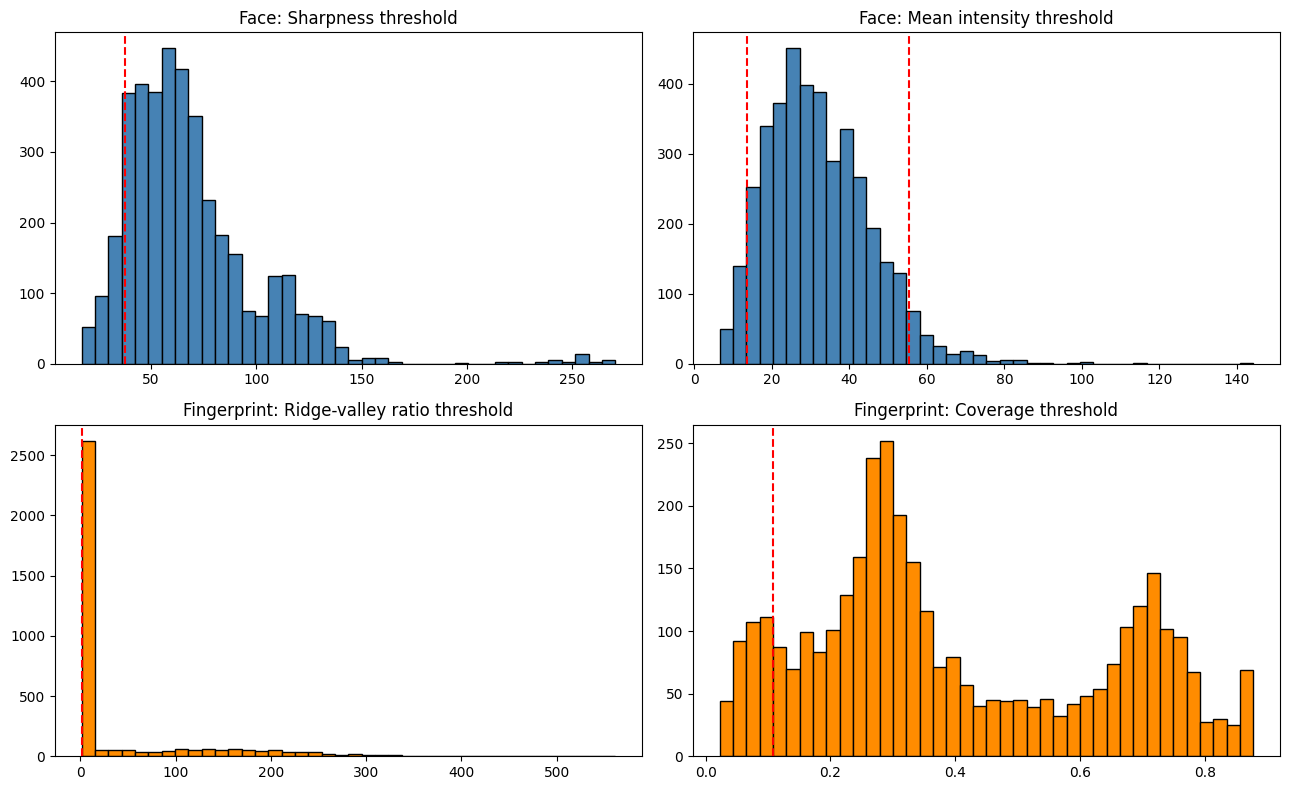


STAGE 2 — FINE-TUNING RESULTS (EdgeFace & MobileNetV3, single modality)

Face (EdgeFace, 512-D) — real-valued embedding, pairwise evaluation:
  Best accuracy : 87.02%  (FAR 10.14%, FRR 15.82%, F1 0.8664)
  EER           : 13.60%

Fingerprint (MobileNetV3, 576-D) — real-valued embedding, pairwise evaluation:
  Best accuracy : 88.86%  (FAR 18.42%, FRR 3.86%, F1 0.8962)
  EER           : 12.77%

Why this matters for fusion: face tends to over-reject (higher FRR), fingerprint tends to over-accept (higher FAR) — opposite failure modes, which is favorable for fusion to cancel out.

STAGE 3 — FUSION RATIO SWEEP (why 55/45)

 Face wt   FP wt   Accuracy      FAR      FRR       F1
    0.05    0.95     88.30%   19.70%    3.69%   0.8917
    0.10    0.90     88.45%   19.60%    3.50%   0.8931
    0.15    0.85     88.73%   19.13%    3.41%   0.8955
    0.20    0.80     89.11%   16.38%    5.40%   0.8968
    0.25    0.75     90.15%   15.06%    4.64%   0.9064
    0.30    0.70     91.57%   12.22%    4.64

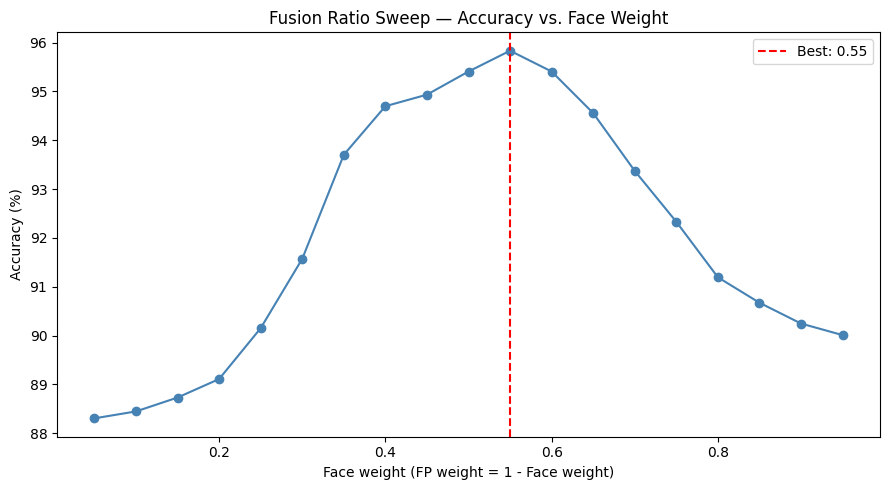


Comparison — before vs after fusion:
  Face alone       : 87.02% accuracy
  Fingerprint alone: 88.86% accuracy
  Fused (55/45)    : 95.83% accuracy  <- fusion improves over both individually

STAGE 4 — BIOHASH GENERATION & FHD THRESHOLD SWEEP

Fused biohash (1088-D -> 128 bits):
  Best threshold: 25 bits (of 128) | Acc 90.77% | FAR 10.13% | FRR 8.33%
  EER: 9.52% at 24 bits

Face-only fallback biohash (512-D -> 128 bits):
  Best threshold: 20 bits (of 128) | Acc 88.17% | FAR 12.30% | FRR 11.37%
  EER: 11.83% at 20 bits

FP-only fallback biohash (576-D -> 128 bits):
  Best threshold: 33 bits (of 128) | Acc 86.08% | FAR 21.52% | FRR 6.32%
  EER: 14.85% at 30 bits

Why these specific thresholds (not a fixed guess like 0.3):
  Each threshold sits near the midpoint between that pathway's genuine and
  imposter FHD distributions — found by sweeping every possible bit-threshold
  (0-128) and picking the one that maximizes accuracy, rather than assuming
  one fixed cutoff works for every path

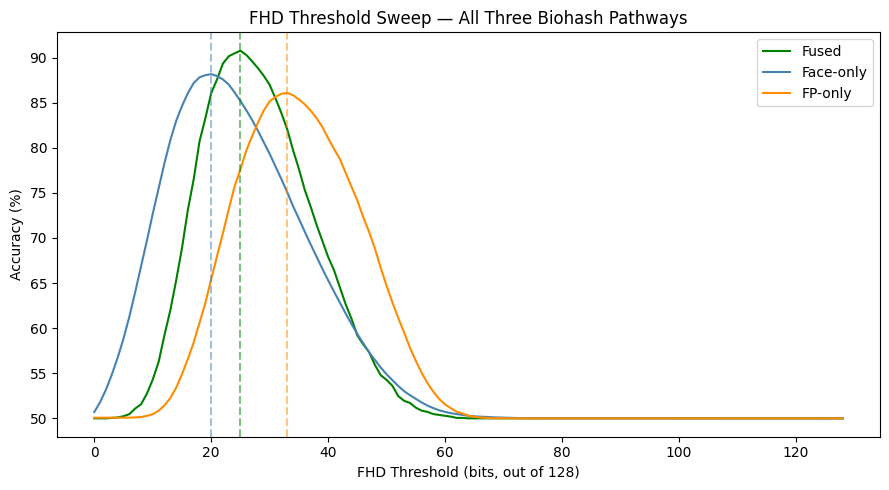


END OF FULL PIPELINE SUMMARY


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'

print("="*70)
print("STAGE 1 — DATASETS & PREPROCESSING (QUALITY CHECK)")
print("="*70)

face_report = pd.read_csv(f'{OUT_DIR}/quality_report_face.csv')
fp_report   = pd.read_csv(f'{OUT_DIR}/quality_report_fp.csv')

print(f"\nNIR Face dataset:")
print(f"  Total images found     : {len(face_report)}")
print(f"  Passed quality check   : {face_report['pass'].sum()} ({face_report['pass'].mean()*100:.1f}%)")
print(f"  Unique persons (total) : {face_report['person_id'].nunique()}")
print(f"  Usable persons (>=2 passed images): "
      f"{(face_report[face_report['pass']].groupby('person_id').size() >= 2).sum()}")

print(f"\nFVC2004 Fingerprint dataset:")
print(f"  Total images found     : {len(fp_report)}")
print(f"  Passed quality check   : {fp_report['pass'].sum()} ({fp_report['pass'].mean()*100:.1f}%)")
print(f"  Unique persons (total) : {fp_report['person_id'].nunique()}")
print(f"  Usable persons (>=2 passed images): "
      f"{(fp_report[fp_report['pass']].groupby('person_id').size() >= 2).sum()}")

# ── QUALITY METRIC THRESHOLDS USED (data-driven, 10th percentile cutoff) ────
print(f"\n--- Face quality metrics & thresholds (bottom 10th percentile cutoff) ---")
print(f"  Metric 1: Sharpness (Laplacian variance)")
print(f"    Threshold: >= {np.percentile(face_report['sharpness'], 10):.2f}")
print(f"    Why: catches blur/motion/out-of-focus captures")
print(f"  Metric 2: Mean pixel intensity")
print(f"    Threshold: {np.percentile(face_report['mean_intensity'], 5):.2f} <= x <= "
      f"{np.percentile(face_report['mean_intensity'], 95):.2f}")
print(f"    Why: rejects over/under-exposed NIR captures (both extremes)")

print(f"\n--- Fingerprint quality metrics & thresholds (bottom 10th percentile cutoff) ---")
print(f"  Metric 1: Ridge-to-valley ratio")
print(f"    Threshold: >= {np.percentile(fp_report['ridge_valley_ratio'], 10):.4f}")
print(f"    Why: catches smudged/worn/dry-finger prints with poor ridge definition")
print(f"  Metric 2: Ridge coverage area")
print(f"    Threshold: >= {np.percentile(fp_report['coverage'], 10):.4f}")
print(f"    Why: catches partial/incomplete finger placement on the sensor")

# ── PLOT: quality distributions with thresholds marked ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0,0].hist(face_report['sharpness'], bins=40, color='steelblue', edgecolor='black')
axes[0,0].axvline(np.percentile(face_report['sharpness'],10), color='red', ls='--')
axes[0,0].set_title('Face: Sharpness threshold')

axes[0,1].hist(face_report['mean_intensity'], bins=40, color='steelblue', edgecolor='black')
axes[0,1].axvline(np.percentile(face_report['mean_intensity'],5), color='red', ls='--')
axes[0,1].axvline(np.percentile(face_report['mean_intensity'],95), color='red', ls='--')
axes[0,1].set_title('Face: Mean intensity threshold')

axes[1,0].hist(fp_report['ridge_valley_ratio'], bins=40, color='darkorange', edgecolor='black')
axes[1,0].axvline(np.percentile(fp_report['ridge_valley_ratio'],10), color='red', ls='--')
axes[1,0].set_title('Fingerprint: Ridge-valley ratio threshold')

axes[1,1].hist(fp_report['coverage'], bins=40, color='darkorange', edgecolor='black')
axes[1,1].axvline(np.percentile(fp_report['coverage'],10), color='red', ls='--')
axes[1,1].set_title('Fingerprint: Coverage threshold')
plt.tight_layout()
plt.show()


print("\n" + "="*70)
print("STAGE 2 — FINE-TUNING RESULTS (EdgeFace & MobileNetV3, single modality)")
print("="*70)

face_sweep = pd.read_csv(f'{OUT_DIR}/face_threshold_sweep.csv')
fp_sweep   = pd.read_csv(f'{OUT_DIR}/fp_threshold_sweep.csv')

face_best_acc = face_sweep.loc[face_sweep['accuracy'].idxmax()]
face_eer_idx  = (face_sweep['far']-face_sweep['frr']).abs().idxmin()
face_eer_row  = face_sweep.loc[face_eer_idx]

fp_best_acc = fp_sweep.loc[fp_sweep['accuracy'].idxmax()]
fp_eer_idx  = (fp_sweep['far']-fp_sweep['frr']).abs().idxmin()
fp_eer_row  = fp_sweep.loc[fp_eer_idx]

print(f"\nFace (EdgeFace, 512-D) — real-valued embedding, pairwise evaluation:")
print(f"  Best accuracy : {face_best_acc['accuracy']*100:.2f}%  (FAR {face_best_acc['far']*100:.2f}%, "
      f"FRR {face_best_acc['frr']*100:.2f}%, F1 {face_best_acc['f1']:.4f})")
print(f"  EER           : {(face_eer_row['far']+face_eer_row['frr'])/2*100:.2f}%")

print(f"\nFingerprint (MobileNetV3, 576-D) — real-valued embedding, pairwise evaluation:")
print(f"  Best accuracy : {fp_best_acc['accuracy']*100:.2f}%  (FAR {fp_best_acc['far']*100:.2f}%, "
      f"FRR {fp_best_acc['frr']*100:.2f}%, F1 {fp_best_acc['f1']:.4f})")
print(f"  EER           : {(fp_eer_row['far']+fp_eer_row['frr'])/2*100:.2f}%")

print(f"\nWhy this matters for fusion: face tends to over-reject (higher FRR), "
      f"fingerprint tends to over-accept (higher FAR) — opposite failure modes, "
      f"which is favorable for fusion to cancel out.")


print("\n" + "="*70)
print("STAGE 3 — FUSION RATIO SWEEP (why 55/45)")
print("="*70)

fusion_sweep = pd.read_csv(f'{OUT_DIR}/fusion_ratio_sweep.csv')
best_fusion = fusion_sweep.loc[fusion_sweep['accuracy'].idxmax()]

print(f"\n{'Face wt':>8} {'FP wt':>7} {'Accuracy':>10} {'FAR':>8} {'FRR':>8} {'F1':>8}")
for _, row in fusion_sweep.iterrows():
    marker = "  <-- BEST" if row['face_weight'] == best_fusion['face_weight'] else ""
    print(f"{row['face_weight']:>8.2f} {row['fp_weight']:>7.2f} {row['accuracy']*100:>9.2f}% "
          f"{row['far']*100:>7.2f}% {row['frr']*100:>7.2f}% {row['f1']:>8.4f}{marker}")

print(f"\nBest ratio: Face {best_fusion['face_weight']} / FP {best_fusion['fp_weight']}")
print(f"  Accuracy: {best_fusion['accuracy']*100:.2f}% | FAR: {best_fusion['far']*100:.2f}% | "
      f"FRR: {best_fusion['frr']*100:.2f}% | F1: {best_fusion['f1']:.4f}")
print(f"\nWhy 55/45: it's the empirical peak of a smooth, single-peaked curve "
      f"(not a fluke — accuracy rises steadily to this point, then falls steadily after). "
      f"It also roughly balances each model's contribution proportional to its individual "
      f"strength (face EER {(face_eer_row['far']+face_eer_row['frr'])/2*100:.2f}% vs "
      f"fingerprint EER {(fp_eer_row['far']+fp_eer_row['frr'])/2*100:.2f}% — nearly equal, "
      f"so a near-even split with a slight face lean makes sense).")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(fusion_sweep['face_weight'], fusion_sweep['accuracy']*100, marker='o', color='steelblue')
ax.axvline(best_fusion['face_weight'], color='red', ls='--', label=f"Best: {best_fusion['face_weight']}")
ax.set_xlabel('Face weight (FP weight = 1 - Face weight)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Fusion Ratio Sweep — Accuracy vs. Face Weight')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nComparison — before vs after fusion:")
print(f"  Face alone       : {face_best_acc['accuracy']*100:.2f}% accuracy")
print(f"  Fingerprint alone: {fp_best_acc['accuracy']*100:.2f}% accuracy")
print(f"  Fused (55/45)    : {best_fusion['accuracy']*100:.2f}% accuracy  <- fusion improves over both individually")


print("\n" + "="*70)
print("STAGE 4 — BIOHASH GENERATION & FHD THRESHOLD SWEEP")
print("="*70)

fused_fhd = pd.read_csv(f'{OUT_DIR}/fhd_threshold_sweep.csv')
face_fhd  = pd.read_csv(f'{OUT_DIR}/fhd_threshold_sweep_face_only.csv')
fp_fhd    = pd.read_csv(f'{OUT_DIR}/fhd_threshold_sweep_fp_only.csv')

def summarize_fhd(df, label):
    best = df.loc[df['accuracy'].idxmax()]
    eer_idx = (df['far']-df['frr']).abs().idxmin()
    eer = df.loc[eer_idx]
    print(f"\n{label}:")
    print(f"  Best threshold: {best['threshold_bits']:.0f} bits (of 128) | "
          f"Acc {best['accuracy']*100:.2f}% | FAR {best['far']*100:.2f}% | FRR {best['frr']*100:.2f}%")
    print(f"  EER: {(eer['far']+eer['frr'])/2*100:.2f}% at {eer['threshold_bits']:.0f} bits")
    return best, eer

fused_best, fused_eer = summarize_fhd(fused_fhd, "Fused biohash (1088-D -> 128 bits)")
face_hash_best, face_hash_eer = summarize_fhd(face_fhd, "Face-only fallback biohash (512-D -> 128 bits)")
fp_hash_best, fp_hash_eer = summarize_fhd(fp_fhd, "FP-only fallback biohash (576-D -> 128 bits)")

print(f"\nWhy these specific thresholds (not a fixed guess like 0.3):")
print(f"  Each threshold sits near the midpoint between that pathway's genuine and")
print(f"  imposter FHD distributions — found by sweeping every possible bit-threshold")
print(f"  (0-128) and picking the one that maximizes accuracy, rather than assuming")
print(f"  one fixed cutoff works for every pathway (they don't — fused, face-only, and")
print(f"  fp-only each have different discriminative power and need different thresholds).")

print(f"\nComparison — real-valued fusion accuracy vs. after biohash compression:")
print(f"  Fused, real-valued (pre-biohash) : {best_fusion['accuracy']*100:.2f}%")
print(f"  Fused, biohash (128-bit)         : {fused_best['accuracy']*100:.2f}%  <- ~5pt drop from binarization")
print(f"  Face-only biohash                : {face_hash_best['accuracy']*100:.2f}%")
print(f"  FP-only biohash                  : {fp_hash_best['accuracy']*100:.2f}%  "
      f"(FAR {fp_hash_best['far']*100:.2f}% — notably higher, flagged for staff review when used)")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(fused_fhd['threshold_bits'], fused_fhd['accuracy']*100, label='Fused', color='green')
ax.plot(face_fhd['threshold_bits'], face_fhd['accuracy']*100, label='Face-only', color='steelblue')
ax.plot(fp_fhd['threshold_bits'], fp_fhd['accuracy']*100, label='FP-only', color='darkorange')
ax.axvline(fused_best['threshold_bits'], color='green', ls='--', alpha=0.5)
ax.axvline(face_hash_best['threshold_bits'], color='steelblue', ls='--', alpha=0.5)
ax.axvline(fp_hash_best['threshold_bits'], color='darkorange', ls='--', alpha=0.5)
ax.set_xlabel('FHD Threshold (bits, out of 128)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('FHD Threshold Sweep — All Three Biohash Pathways')
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("END OF FULL PIPELINE SUMMARY")
print("="*70)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# UNIFIED PIPELINE — Multimodal Biometric ER Authentication System
# Run this top-to-bottom (Runtime > Run all) in a fresh Colab session.
# Loads everything from Drive — no retraining, no manual step-by-step needed.
# ═══════════════════════════════════════════════════════════════════════════

# ── SECTION 0: SETUP ──────────────────────────────────────────────────────
!pip install faiss-cpu cryptography -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from google.colab import userdata
from cryptography.fernet import Fernet
import numpy as np
import pandas as pd
import sqlite3
import faiss
import random
from collections import defaultdict

BASE    = '/content/drive/MyDrive/BiometricProject'
OUT_DIR = f'{BASE}/quality_reports'
DB_PATH = f'{BASE}/patient_biohash.db'

print("="*70)
print("SECTION 0: SETUP COMPLETE")
print("="*70)


# ── SECTION 1: LOAD ENCRYPTION KEY, DATABASE, SAVED MODEL ARTIFACTS ─────────
encryption_key = userdata.get('BIOHASH_ENCRYPTION_KEY')
fernet = Fernet(encryption_key.encode())

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS patients (
    patient_id TEXT PRIMARY KEY,
    enrolled_at TEXT NOT NULL,
    fused_biohash TEXT,
    face_only_biohash TEXT,
    fp_only_biohash TEXT,
    has_face_sample INTEGER NOT NULL,
    has_fp_sample INTEGER NOT NULL,
    encrypted_fused_embedding BLOB
)
''')
cursor.execute('''
CREATE TABLE IF NOT EXISTS doctors (
    doctor_reg_code TEXT PRIMARY KEY,
    doctor_name TEXT
)
''')
conn.commit()

jl_fused = np.load(f'{BASE}/jl_projection_matrix.npy')
jl_face  = np.load(f'{BASE}/jl_matrix_face512.npy')
jl_fp    = np.load(f'{BASE}/jl_matrix_fp576.npy')

face_embeddings = np.load(f'{OUT_DIR}/face_embeddings.npy', allow_pickle=True).item()
fp_embeddings   = np.load(f'{OUT_DIR}/fp_embeddings.npy', allow_pickle=True).item()

face_person_embs = defaultdict(list)
for k, v in face_embeddings.items():
    face_person_embs[v['person_id']].append(v['embedding'])
fp_person_embs = defaultdict(list)
for k, v in fp_embeddings.items():
    fp_person_embs[v['person_id']].append(v['embedding'])

print("="*70)
print("SECTION 1: KEY, DATABASE, EMBEDDINGS, JL MATRICES LOADED")
print(f"  Face persons available : {len(face_person_embs)}")
print(f"  FP persons available   : {len(fp_person_embs)}")
print("="*70)


# ── SECTION 2: CORE FUNCTIONS ────────────────────────────────────────────────
def encrypt_embedding(embedding_array):
    return fernet.encrypt(embedding_array.astype(np.float32).tobytes())

def decrypt_embedding(encrypted_blob, dim):
    return np.frombuffer(fernet.decrypt(encrypted_blob), dtype=np.float32).reshape(dim)

def biohash_to_str(arr):
    return ''.join(arr.astype(str))

def hamming_distance_str(h1, h2):
    a = np.array(list(h1), dtype=np.uint8)
    b = np.array(list(h2), dtype=np.uint8)
    return int(np.sum(a != b))

def enroll_patient(patient_id, face_emb, fp_emb, w_face=0.55, w_fp=0.45):
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb])
    fused_hash = biohash_to_str((fused @ jl_fused > 0).astype(np.uint8))
    face_hash  = biohash_to_str((face_emb @ jl_face > 0).astype(np.uint8))
    fp_hash    = biohash_to_str((fp_emb @ jl_fp > 0).astype(np.uint8))
    encrypted_emb = encrypt_embedding(fused)

    cursor.execute('''
        INSERT OR REPLACE INTO patients
        (patient_id, enrolled_at, fused_biohash, face_only_biohash, fp_only_biohash,
         has_face_sample, has_fp_sample, encrypted_fused_embedding)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    ''', (patient_id, str(np.datetime64('now')), fused_hash, face_hash, fp_hash,
          1, 1, encrypted_emb))
    conn.commit()

def enroll_doctor(doctor_reg_code, doctor_name):
    cursor.execute('INSERT OR REPLACE INTO doctors VALUES (?, ?)', (doctor_reg_code, doctor_name))
    conn.commit()

def verify_doctor_code(doctor_reg_code):
    cursor.execute('SELECT doctor_name FROM doctors WHERE doctor_reg_code = ?', (doctor_reg_code,))
    row = cursor.fetchone()
    return (True, row[0]) if row else (False, None)

def manual_patient_lookup(patient_id):
    cursor.execute("SELECT patient_id FROM patients WHERE patient_id = ?", (patient_id,))
    return cursor.fetchone() is not None

def build_embedding_faiss_index():
    cursor.execute("SELECT patient_id, encrypted_fused_embedding FROM patients")
    rows = cursor.fetchall()
    if not rows:
        return None, []
    id_lookup, vectors = [], []
    for patient_id, enc_blob in rows:
        vectors.append(decrypt_embedding(enc_blob, 1088))
        id_lookup.append(patient_id)
    vectors = np.vstack(vectors).astype(np.float32)
    index = faiss.IndexFlatL2(1088)
    index.add(vectors)
    return index, id_lookup

def identify_shortlist(face_emb, fp_emb, embedding_index, id_lookup,
                        w_face=0.55, w_fp=0.45, k=3, l2_cutoff=0.13):
    fused = np.concatenate([w_face * face_emb, w_fp * fp_emb]).astype(np.float32).reshape(1, -1)
    k_search = min(k, embedding_index.ntotal)
    distances, indices = embedding_index.search(fused, k_search)
    return [{"patient_id": id_lookup[idx], "l2_distance": float(dist)}
            for dist, idx in zip(distances[0], indices[0]) if dist <= l2_cutoff]

def er_access_flow(face_emb, fp_emb, doctor_reg_code, embedding_index, id_lookup,
                    manual_patient_id=None, w_face=0.55, w_fp=0.45):
    shortlist = identify_shortlist(face_emb, fp_emb, embedding_index, id_lookup, w_face, w_fp)
    shortlist_ids = [c["patient_id"] for c in shortlist]

    if manual_patient_id is not None:
        if not manual_patient_lookup(manual_patient_id):
            return {"access_granted": False, "stage_failed": "manual_lookup_invalid",
                    "reason": "No such patient_id.", "biometric_shortlist_shown": shortlist}
        confirmed_id, method = manual_patient_id, "manual_fallback"
    elif shortlist_ids:
        confirmed_id, method = shortlist_ids[0], "biometric_shortlist"
    else:
        return {"access_granted": False, "stage_failed": "no_identification",
                "reason": "No biometric match — use manual lookup.", "biometric_shortlist_shown": []}

    doctor_valid, doctor_name = verify_doctor_code(doctor_reg_code)
    if not doctor_valid:
        return {"access_granted": False, "stage_failed": "doctor_verification",
                "candidate_patient_id": confirmed_id, "identification_method": method,
                "reason": "Invalid doctor registration code."}

    return {"access_granted": True, "patient_id": confirmed_id,
            "identification_method": method, "biometric_shortlist_shown": shortlist,
            "verified_by": doctor_name}

print("="*70)
print("SECTION 2: ALL CORE FUNCTIONS DEFINED")
print("="*70)


# ── SECTION 3: ENSURE DEMO DATA EXISTS (enrolls population if DB is empty) ──
cursor.execute("SELECT COUNT(*) FROM patients")
existing_count = cursor.fetchone()[0]

if existing_count == 0:
    print("Database empty — enrolling full population from saved embeddings...")
    face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
    fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]
    random.seed(42)
    random.shuffle(face_persons)
    random.shuffle(fp_persons)
    n_virtual = min(len(face_persons), len(fp_persons))

    enrolled_map = {}
    for i in range(n_virtual):
        pid = f"MCI-{2000+i}"
        enroll_patient(pid, face_person_embs[face_persons[i]][0], fp_person_embs[fp_persons[i]][0])
        enrolled_map[pid] = (face_persons[i], fp_persons[i])
    print(f"Enrolled {len(enrolled_map)} patients.")
else:
    print(f"Database already has {existing_count} enrolled patients — reusing existing data.")
    # rebuild enrolled_map for the demo lookup below (person mapping only, not re-enrolling)
    face_persons = [p for p, e in face_person_embs.items() if len(e) >= 2]
    fp_persons   = [p for p, e in fp_person_embs.items() if len(e) >= 2]
    random.seed(42)
    random.shuffle(face_persons)
    random.shuffle(fp_persons)
    n_virtual = min(len(face_persons), len(fp_persons))
    enrolled_map = {f"MCI-{2000+i}": (face_persons[i], fp_persons[i]) for i in range(n_virtual)}

if not verify_doctor_code("DOC-1001")[0]:
    enroll_doctor("DOC-1001", "Dr. Test Physician")
    print("Demo doctor enrolled: DOC-1001")

embedding_index, id_lookup = build_embedding_faiss_index()
print(f"\nFAISS index built: {len(id_lookup)} patients ready for identification.")

print("="*70)
print("SECTION 3: DATABASE + FAISS INDEX READY")
print("="*70)


# ── SECTION 4: DEMO — SIMULATED ER VISIT ────────────────────────────────────
# In production, face_emb/fp_emb come from live camera+sensor scans run
# through the fine-tuned EdgeFace/MobileNetV3 models. Here we simulate a
# "new visit" using a held-out sample (not the one used at enrollment) for
# a real enrolled patient, to demonstrate the full flow without live hardware.

demo_patient_id = list(enrolled_map.keys())[10]
demo_face_p, demo_fp_p = enrolled_map[demo_patient_id]

if len(face_person_embs[demo_face_p]) > 1 and len(fp_person_embs[demo_fp_p]) > 1:
    live_face_emb = face_person_embs[demo_face_p][1]
    live_fp_emb   = fp_person_embs[demo_fp_p][1]

    print(f"\n--- DEMO: ER visit, true patient is {demo_patient_id} ---")
    result = er_access_flow(live_face_emb, live_fp_emb, "DOC-1001", embedding_index, id_lookup)
    print(result)

    print(f"\n--- DEMO: Same visit, WRONG doctor code (should be denied) ---")
    result_wrong = er_access_flow(live_face_emb, live_fp_emb, "FAKE-CODE", embedding_index, id_lookup)
    print(result_wrong)

    print(f"\n--- DEMO: Manual fallback path (simulating biometric miss) ---")
    result_manual = er_access_flow(np.random.randn(512).astype(np.float32),
                                    np.random.randn(576).astype(np.float32),
                                    "DOC-1001", embedding_index, id_lookup,
                                    manual_patient_id=demo_patient_id)
    print(result_manual)

print("\n" + "="*70)
print("SECTION 4: DEMO COMPLETE — SYSTEM RUNNING END-TO-END")
print("="*70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 83.6 MB/s eta 0:00:00
Mounted at /content/drive
SECTION 0: SETUP COMPLETE
SECTION 1: KEY, DATABASE, EMBEDDINGS, JL MATRICES LOADED
  Face persons available : 191
  FP persons available   : 439
SECTION 2: ALL CORE FUNCTIONS DEFINED
Database already has 189 enrolled patients — reusing existing data.

FAISS index built: 189 patients ready for identification.
SECTION 3: DATABASE + FAISS INDEX READY

--- DEMO: ER visit, true patient is MCI-2010 ---
{'access_granted': True, 'patient_id': 'MCI-2010', 'identification_method': 'biometric_shortlist', 'biometric_shortlist_shown': [{'patient_id': 'MCI-2010', 'l2_distance': 0.08583170175552368}], 'verified_by': 'Dr. Test Physician'}

--- DEMO: Same visit, WRONG doctor code (should be denied) ---
{'access_granted': False, 'stage_failed': 'doctor_verification', 'candidate_patient_id': 'MCI-2010', 'identification_method': 'biometric_shortlist', 'reason': 'Invalid doctor registration code.'}

---

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
import random

OUT_DIR = f'{BASE}/quality_reports'
face_quality_df = pd.read_csv(f'{OUT_DIR}/quality_passed_face.csv')
fp_quality_df   = pd.read_csv(f'{OUT_DIR}/quality_passed_fp.csv')

# ── PICK DEMO SCENARIO PATIENTS ONCE ─────────────────────────────────────────
demo_patient_id = list(enrolled_map.keys())[10]
demo_face_p, demo_fp_p = enrolled_map[demo_patient_id]

face_rows = face_quality_df[face_quality_df['person_id'] == demo_face_p].reset_index(drop=True)
fp_rows   = fp_quality_df[fp_quality_df['person_id'] == demo_fp_p].reset_index(drop=True)

live_face_path = face_rows.iloc[1]['path'] if len(face_rows) > 1 else face_rows.iloc[0]['path']
live_fp_path   = fp_rows.iloc[1]['path'] if len(fp_rows) > 1 else fp_rows.iloc[0]['path']
live_face_emb  = face_person_embs[demo_face_p][1] if len(face_person_embs[demo_face_p]) > 1 else face_person_embs[demo_face_p][0]
live_fp_emb    = fp_person_embs[demo_fp_p][1] if len(fp_person_embs[demo_fp_p]) > 1 else fp_person_embs[demo_fp_p][0]

face_row_metrics = face_rows.iloc[1] if len(face_rows) > 1 else face_rows.iloc[0]
fp_row_metrics   = fp_rows.iloc[1] if len(fp_rows) > 1 else fp_rows.iloc[0]

# ── UI ELEMENTS ───────────────────────────────────────────────────────────────
title = widgets.HTML("<h2>🏥 ER Biometric Authentication — Live Demo</h2>")

scenario_dropdown = widgets.Dropdown(
    options=[('Genuine patient, correct doctor code', 'genuine'),
             ('Genuine patient, WRONG doctor code', 'wrong_code'),
             ('Unenrolled imposter', 'imposter'),
             ('Biometric miss → manual fallback', 'manual')],
    description='Scenario:', style={'description_width': 'initial'}
)

scan_button = widgets.Button(description="▶ Start ER Scan", button_style='primary')
output_area = widgets.Output()

def card(title_text, body_html, color="#f0f0f0"):
    return f"""<div style="border-left:6px solid {color}; background:#fafafa; padding:12px 16px;
                margin:8px 0; border-radius:6px;">
                <b>{title_text}</b><br>{body_html}</div>"""

def run_demo(b):
    with output_area:
        clear_output(wait=True)
        scenario = scenario_dropdown.value

        # ── STEP 1: SCAN CAPTURE ─────────────────────────────────────────────
        display(HTML("<h3>Step 1 — Scan Captured</h3>"))
        img_html = f"""
        <div style="display:flex; gap:20px;">
            <div><img src="{live_face_path}" width="140"><br><center>Face scan</center></div>
        </div>
        """
        display(HTML(img_html))

        # ── STEP 2: QUALITY CHECK ────────────────────────────────────────────
        face_pass = "✅ PASS" if face_row_metrics['pass'] else "❌ FAIL"
        fp_pass   = "✅ PASS" if fp_row_metrics['pass'] else "❌ FAIL"
        display(HTML(card("Step 2 — Quality Check",
            f"Face — Sharpness: {face_row_metrics['sharpness']:.1f}, "
            f"Intensity: {face_row_metrics['mean_intensity']:.1f} → {face_pass}<br>"
            f"Fingerprint — Ridge-valley: {fp_row_metrics['ridge_valley_ratio']:.2f}, "
            f"Coverage: {fp_row_metrics['coverage']:.2f} → {fp_pass}",
            color="#4CAF50" if face_row_metrics['pass'] and fp_row_metrics['pass'] else "#f44336")))

        # ── STEP 3: IDENTIFICATION ───────────────────────────────────────────
        if scenario == 'imposter':
            query_face = np.random.randn(512).astype(np.float32)
            query_fp   = np.random.randn(576).astype(np.float32)
        else:
            query_face, query_fp = live_face_emb, live_fp_emb

        shortlist = identify_shortlist(query_face, query_fp, embedding_index, id_lookup)

        if shortlist:
            rows = "".join(f"<li>{c['patient_id']} — similarity distance {c['l2_distance']:.4f}</li>"
                            for c in shortlist)
            display(HTML(card("Step 3 — Biometric Shortlist", f"<ul>{rows}</ul>", color="#2196F3")))
        else:
            display(HTML(card("Step 3 — Biometric Shortlist",
                "No confident match found. Manual lookup required.", color="#FF9800")))

        # ── STEP 4: ACCESS DECISION ───────────────────────────────────────────
        display(HTML("<h3>Step 4 — Access Decision</h3>"))

        if scenario == 'genuine':
            result = er_access_flow(query_face, query_fp, "DOC-1001", embedding_index, id_lookup)
        elif scenario == 'wrong_code':
            result = er_access_flow(query_face, query_fp, "FAKE-CODE-000", embedding_index, id_lookup)
        elif scenario == 'imposter':
            result = er_access_flow(query_face, query_fp, "DOC-1001", embedding_index, id_lookup)
        elif scenario == 'manual':
            result = er_access_flow(np.random.randn(512).astype(np.float32),
                                     np.random.randn(576).astype(np.float32),
                                     "DOC-1001", embedding_index, id_lookup,
                                     manual_patient_id=demo_patient_id)

        if result['access_granted']:
            display(HTML(f"""
            <div style="background:#c8f7c5; border:2px solid #2e7d32; border-radius:10px;
                        padding:20px; text-align:center; font-size:20px;">
                ✅ <b>ACCESS GRANTED</b><br>
                Patient: {result['patient_id']}<br>
                Method: {result['identification_method']}<br>
                Verified by: {result['verified_by']}<br>
                <span style="font-size:14px;">Compressed medical record now visible.</span>
            </div>"""))
        else:
            display(HTML(f"""
            <div style="background:#f8d7da; border:2px solid #c62828; border-radius:10px;
                        padding:20px; text-align:center; font-size:20px;">
                ⛔ <b>ACCESS DENIED</b><br>
                Reason: {result.get('reason', result.get('stage_failed'))}<br>
                <span style="font-size:14px;">No medical data revealed.</span>
            </div>"""))

scan_button.on_click(run_demo)

display(title, scenario_dropdown, scan_button, output_area)

HTML(value='<h2>🏥 ER Biometric Authentication — Live Demo</h2>')

Dropdown(description='Scenario:', options=(('Genuine patient, correct doctor code', 'genuine'), ('Genuine pati…

Button(button_style='primary', description='▶ Start ER Scan', style=ButtonStyle())

Output()

In [ ]:
import zlib
import json

# ── EXTEND SCHEMA: add compressed medical record column ─────────────────────
cursor.execute('''
    ALTER TABLE patients ADD COLUMN compressed_medical_record BLOB
''')
conn.commit()
print("Schema extended with compressed_medical_record column")

OperationalError: duplicate column name: compressed_medical_record

In [ ]:
# ── FUNCTIONS TO STORE/RETRIEVE COMPRESSED MEDICAL RECORDS ───────────────────
def store_medical_record(patient_id, record_dict):
    """Compresses a medical record (dict) with zlib and stores it as a BLOB."""
    json_bytes = json.dumps(record_dict).encode('utf-8')
    compressed = zlib.compress(json_bytes, level=9)
    cursor.execute("UPDATE patients SET compressed_medical_record = ? WHERE patient_id = ?",
                   (compressed, patient_id))
    conn.commit()
    return len(json_bytes), len(compressed)   # (original size, compressed size)

def retrieve_medical_record(patient_id):
    cursor.execute("SELECT compressed_medical_record FROM patients WHERE patient_id = ?", (patient_id,))
    row = cursor.fetchone()
    if row is None or row[0] is None:
        return None
    decompressed = zlib.decompress(row[0])
    return json.loads(decompressed.decode('utf-8'))

# ── SEED A DEMO MEDICAL RECORD FOR THE DEMO PATIENT ──────────────────────────
demo_record = {
    "blood_type": "O+",
    "allergies": ["Penicillin", "Latex"],
    "chronic_conditions": ["Type 2 Diabetes", "Hypertension"],
    "current_medications": ["Metformin 500mg", "Amlodipine 5mg"],
    "last_visit": "2026-06-14",
    "last_visit_reason": "Routine diabetes follow-up",
    "emergency_contact": "Spouse — +91-XXXXXXXXXX",
    "notes": "Patient reports occasional dizziness. No known cardiac history."
}

orig_size, comp_size = store_medical_record(demo_patient_id, demo_record)
print(f"Medical record stored for {demo_patient_id}")
print(f"Original size: {orig_size} bytes | Compressed size: {comp_size} bytes "
      f"({comp_size/orig_size*100:.1f}% of original)")

Medical record stored for MCI-2010
Original size: 387 bytes | Compressed size: 269 bytes (69.5% of original)


In [ ]:
# Add this right after computing live_face_path / live_fp_path near the top
print("Face image path:", live_face_path)
print("Fingerprint image path:", live_fp_path)

Face image path: /content/drive/MyDrive/BiometricProject/Nir face/NIR_face_dataset/NIR_face_dataset/0018-14-a.bmp
Fingerprint image path: /content/drive/MyDrive/BiometricProject/FVC2004/FVC2004/Dbs/DB4_A/32_1.tif


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
import zlib
import json

OUT_DIR = f'{BASE}/quality_reports'
face_quality_df = pd.read_csv(f'{OUT_DIR}/quality_passed_face.csv')
fp_quality_df   = pd.read_csv(f'{OUT_DIR}/quality_passed_fp.csv')

# ── MEDICAL RECORD STORAGE (zlib-compressed) ─────────────────────────────────
try:
    cursor.execute('ALTER TABLE patients ADD COLUMN compressed_medical_record BLOB')
    conn.commit()
except Exception:
    pass   # column already exists

def store_medical_record(patient_id, record_dict):
    json_bytes = json.dumps(record_dict).encode('utf-8')
    compressed = zlib.compress(json_bytes, level=9)
    cursor.execute("UPDATE patients SET compressed_medical_record = ? WHERE patient_id = ?",
                   (compressed, patient_id))
    conn.commit()
    return len(json_bytes), len(compressed)

def retrieve_medical_record(patient_id):
    cursor.execute("SELECT compressed_medical_record FROM patients WHERE patient_id = ?", (patient_id,))
    row = cursor.fetchone()
    if row is None or row[0] is None:
        return None
    return json.loads(zlib.decompress(row[0]).decode('utf-8'))

# ── DEMO PATIENT + SCAN IMAGES ────────────────────────────────────────────────
demo_patient_id = list(enrolled_map.keys())[10]
demo_face_p, demo_fp_p = enrolled_map[demo_patient_id]

face_rows = face_quality_df[face_quality_df['person_id'] == demo_face_p].reset_index(drop=True)
fp_rows   = fp_quality_df[fp_quality_df['person_id'] == demo_fp_p].reset_index(drop=True)

live_face_path = face_rows.iloc[1]['path'] if len(face_rows) > 1 else face_rows.iloc[0]['path']
live_fp_path   = fp_rows.iloc[1]['path'] if len(fp_rows) > 1 else fp_rows.iloc[0]['path']
live_face_emb  = face_person_embs[demo_face_p][1] if len(face_person_embs[demo_face_p]) > 1 else face_person_embs[demo_face_p][0]
live_fp_emb    = fp_person_embs[demo_fp_p][1] if len(fp_person_embs[demo_fp_p]) > 1 else fp_person_embs[demo_fp_p][0]

face_row_metrics = face_rows.iloc[1] if len(face_rows) > 1 else face_rows.iloc[0]
fp_row_metrics   = fp_rows.iloc[1] if len(fp_rows) > 1 else fp_rows.iloc[0]

print("Face image path:", live_face_path)
print("Fingerprint image path:", live_fp_path)

# ── IMPOSTER — genuinely different real person's images ─────────────────────
imposter_face_person = [p for p in face_person_embs if p != demo_face_p][30]
imposter_fp_person   = [p for p in fp_person_embs if p != demo_fp_p][30]

imposter_face_rows = face_quality_df[face_quality_df['person_id'] == imposter_face_person].reset_index(drop=True)
imposter_fp_rows   = fp_quality_df[fp_quality_df['person_id'] == imposter_fp_person].reset_index(drop=True)

imposter_face_path = imposter_face_rows.iloc[0]['path']
imposter_fp_path   = imposter_fp_rows.iloc[0]['path']

# ── SEED DEMO MEDICAL RECORD ──────────────────────────────────────────────────
demo_record = {
    "blood_type": "O+",
    "allergies": ["Penicillin", "Latex"],
    "chronic_conditions": ["Type 2 Diabetes", "Hypertension"],
    "current_medications": ["Metformin 500mg", "Amlodipine 5mg"],
    "last_visit": "2026-06-14",
    "last_visit_reason": "Routine diabetes follow-up",
    "emergency_contact": "Spouse — +91-XXXXXXXXXX",
    "notes": "Patient reports occasional dizziness. No known cardiac history."
}
orig_size, comp_size = store_medical_record(demo_patient_id, demo_record)
print(f"Medical record stored for {demo_patient_id}: {orig_size}B -> {comp_size}B "
      f"({comp_size/orig_size*100:.1f}% of original)")

# ── UI HELPERS ────────────────────────────────────────────────────────────────
def card(title_text, body_html, color="#f0f0f0"):
    return f"""<div style="border-left:6px solid {color}; background:#fafafa; padding:12px 16px;
                margin:8px 0; border-radius:6px;">
                <b>{title_text}</b><br>{body_html}</div>"""

def medical_record_card(record):
    allergies = ", ".join(record["allergies"]) if record["allergies"] else "None recorded"
    conditions = ", ".join(record["chronic_conditions"]) if record["chronic_conditions"] else "None recorded"
    meds = "<br>".join(record["current_medications"]) if record["current_medications"] else "None"
    return f"""
    <div style="border:2px solid #1565c0; border-radius:10px; padding:18px; margin-top:14px;
                background:#f4f8ff; font-family:sans-serif;">
        <h3 style="margin-top:0; color:#1565c0;">📋 Patient Medical Record</h3>
        <table style="width:100%; font-size:14px; border-collapse:collapse;">
            <tr><td style="padding:4px; font-weight:bold; width:180px;">Blood Type</td><td>{record['blood_type']}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Allergies</td><td style="color:#c62828;">{allergies}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Chronic Conditions</td><td>{conditions}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Current Medications</td><td>{meds}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Last Visit</td><td>{record['last_visit']} — {record['last_visit_reason']}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Emergency Contact</td><td>{record['emergency_contact']}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Notes</td><td>{record['notes']}</td></tr>
        </table>
    </div>
    """

# ── UI WIDGETS ────────────────────────────────────────────────────────────────
title = widgets.HTML("<h2>🏥 ER Biometric Authentication — Live Demo</h2>")

scenario_dropdown = widgets.Dropdown(
    options=[('Genuine patient, correct doctor code', 'genuine'),
             ('Genuine patient, WRONG doctor code', 'wrong_code'),
             ('Unenrolled imposter', 'imposter'),
             ('Biometric miss → manual fallback', 'manual')],
    description='Scenario:', style={'description_width': 'initial'}
)

scan_button = widgets.Button(description="▶ Start ER Scan", button_style='primary')
output_area = widgets.Output()

def run_demo(b):
    with output_area:
        clear_output(wait=True)
        scenario = scenario_dropdown.value

        # ── choose which real images to display based on scenario ───────────
        if scenario == 'imposter':
            display_face_path, display_fp_path = imposter_face_path, imposter_fp_path
        else:
            display_face_path, display_fp_path = live_face_path, live_fp_path

        display(HTML("<h3>Step 1 — Scan Captured</h3>"))
        display(HTML(f"""
        <div style="display:flex; gap:30px; align-items:flex-start;">
            <div style="text-align:center;">
                <img src="{display_face_path}" width="140" style="border:2px solid #ccc; border-radius:6px;">
                <br><b>NIR Face Scan</b>
            </div>
            <div style="text-align:center;">
                <img src="{display_fp_path}" width="140" style="border:2px solid #ccc; border-radius:6px;">
                <br><b>Fingerprint Scan</b>
            </div>
        </div>
        """))

        # ── Step 2: quality check ────────────────────────────────────────────
        face_pass = "✅ PASS" if face_row_metrics['pass'] else "❌ FAIL"
        fp_pass   = "✅ PASS" if fp_row_metrics['pass'] else "❌ FAIL"
        display(HTML(card("Step 2 — Quality Check",
            f"Face — Sharpness: {face_row_metrics['sharpness']:.1f}, "
            f"Intensity: {face_row_metrics['mean_intensity']:.1f} → {face_pass}<br>"
            f"Fingerprint — Ridge-valley: {fp_row_metrics['ridge_valley_ratio']:.2f}, "
            f"Coverage: {fp_row_metrics['coverage']:.2f} → {fp_pass}",
            color="#4CAF50" if face_row_metrics['pass'] and fp_row_metrics['pass'] else "#f44336")))

        # ── Step 3: identification ───────────────────────────────────────────
        if scenario == 'imposter':
            query_face = np.random.randn(512).astype(np.float32)
            query_fp   = np.random.randn(576).astype(np.float32)
        else:
            query_face, query_fp = live_face_emb, live_fp_emb

        shortlist = identify_shortlist(query_face, query_fp, embedding_index, id_lookup)
        if shortlist:
            rows = "".join(f"<li>{c['patient_id']} — similarity distance {c['l2_distance']:.4f}</li>"
                            for c in shortlist)
            display(HTML(card("Step 3 — Biometric Shortlist", f"<ul>{rows}</ul>", color="#2196F3")))
        else:
            display(HTML(card("Step 3 — Biometric Shortlist",
                "No confident match found. Manual lookup required.", color="#FF9800")))

        # ── Step 4: access decision ──────────────────────────────────────────
        display(HTML("<h3>Step 4 — Access Decision</h3>"))

        if scenario == 'genuine':
            result = er_access_flow(query_face, query_fp, "DOC-1001", embedding_index, id_lookup)
        elif scenario == 'wrong_code':
            result = er_access_flow(query_face, query_fp, "FAKE-CODE-000", embedding_index, id_lookup)
        elif scenario == 'imposter':
            result = er_access_flow(query_face, query_fp, "DOC-1001", embedding_index, id_lookup)
        elif scenario == 'manual':
            result = er_access_flow(np.random.randn(512).astype(np.float32),
                                     np.random.randn(576).astype(np.float32),
                                     "DOC-1001", embedding_index, id_lookup,
                                     manual_patient_id=demo_patient_id)

        if result['access_granted']:
            display(HTML(f"""
            <div style="background:#c8f7c5; border:2px solid #2e7d32; border-radius:10px;
                        padding:20px; text-align:center; font-size:20px;">
                ✅ <b>ACCESS GRANTED</b><br>
                Patient: {result['patient_id']}<br>
                Method: {result['identification_method']}<br>
                Verified by: {result['verified_by']}
            </div>"""))

            record = retrieve_medical_record(result['patient_id'])
            if record:
                display(HTML(medical_record_card(record)))
            else:
                display(HTML(card("Medical Record",
                    "No record stored for this patient (demo data only seeded for one patient).",
                    color="#9e9e9e")))
        else:
            display(HTML(f"""
            <div style="background:#f8d7da; border:2px solid #c62828; border-radius:10px;
                        padding:20px; text-align:center; font-size:20px;">
                ⛔ <b>ACCESS DENIED</b><br>
                Reason: {result.get('reason', result.get('stage_failed'))}<br>
                <span style="font-size:14px;">No medical data revealed.</span>
            </div>"""))

scan_button.on_click(run_demo)
display(title, scenario_dropdown, scan_button, output_area)

Face image path: /content/drive/MyDrive/BiometricProject/Nir face/NIR_face_dataset/NIR_face_dataset/0018-14-a.bmp
Fingerprint image path: /content/drive/MyDrive/BiometricProject/FVC2004/FVC2004/Dbs/DB4_A/32_1.tif
Medical record stored for MCI-2010: 387B -> 269B (69.5% of original)


HTML(value='<h2>🏥 ER Biometric Authentication — Live Demo</h2>')

Dropdown(description='Scenario:', options=(('Genuine patient, correct doctor code', 'genuine'), ('Genuine pati…

Button(button_style='primary', description='▶ Start ER Scan', style=ButtonStyle())

Output()

In [ ]:
import faiss
import numpy as np

def build_single_modality_indices():
    face_ids, face_vecs = [], []
    fp_ids, fp_vecs = [], []
    for pid, (face_p, fp_p) in enrolled_map.items():
        face_vecs.append(face_person_embs[face_p][0])
        face_ids.append(pid)
        fp_vecs.append(fp_person_embs[fp_p][0])
        fp_ids.append(pid)

    face_index = faiss.IndexFlatL2(512)
    face_index.add(np.vstack(face_vecs).astype(np.float32))

    fp_index = faiss.IndexFlatL2(576)
    fp_index.add(np.vstack(fp_vecs).astype(np.float32))

    return face_index, face_ids, fp_index, fp_ids

face_only_index, face_only_ids, fp_only_index, fp_only_ids = build_single_modality_indices()
print("Face-only and FP-only fallback indices built.")

def identify_pathway(face_emb, fp_emb, l2_cutoff_fused=0.13, l2_cutoff_single=0.5):
    if face_emb is not None and fp_emb is not None:
        shortlist = identify_shortlist(face_emb, fp_emb, embedding_index, id_lookup,
                                        l2_cutoff=l2_cutoff_fused)
        return "fused", shortlist
    elif face_emb is not None and fp_emb is None:
        query = face_emb.astype(np.float32).reshape(1, -1)
        distances, indices = face_only_index.search(query, min(3, face_only_index.ntotal))
        shortlist = [{"patient_id": face_only_ids[i], "l2_distance": float(d)}
                     for d, i in zip(distances[0], indices[0]) if d <= l2_cutoff_single]
        return "face_only", shortlist
    elif face_emb is None and fp_emb is not None:
        query = fp_emb.astype(np.float32).reshape(1, -1)
        distances, indices = fp_only_index.search(query, min(3, fp_only_index.ntotal))
        shortlist = [{"patient_id": fp_only_ids[i], "l2_distance": float(d)}
                     for d, i in zip(distances[0], indices[0]) if d <= l2_cutoff_single]
        return "fp_only", shortlist
    return "none", []

def er_access_flow_v3(face_emb, fp_emb, doctor_reg_code):
    pathway, shortlist = identify_pathway(face_emb, fp_emb)
    shortlist_ids = [c["patient_id"] for c in shortlist]

    if not shortlist_ids:
        return {"access_granted": False, "stage_failed": "no_identification",
                "pathway": pathway, "reason": "No biometric match found.", "shortlist": []}

    confirmed_id = shortlist_ids[0]
    doctor_valid, doctor_name = verify_doctor_code(doctor_reg_code)
    if not doctor_valid:
        return {"access_granted": False, "stage_failed": "doctor_verification",
                "pathway": pathway, "candidate_patient_id": confirmed_id,
                "reason": "Invalid doctor registration code.", "shortlist": shortlist}

    return {"access_granted": True, "patient_id": confirmed_id, "pathway": pathway,
            "verified_by": doctor_name, "shortlist": shortlist}

print("Unified 3-pathway identification ready.")

Face-only and FP-only fallback indices built.
Unified 3-pathway identification ready.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

title = widgets.HTML("<h2>🏥 ER Biometric Authentication — Live Demo</h2>")

scenario_dropdown = widgets.Dropdown(
    options=[
        ('1. Both face + fingerprint pass quality, correct doctor code', 'both_correct'),
        ('2. Both pass quality, WRONG doctor code', 'both_wrong_code'),
        ('3. Face FAILS quality → fingerprint-only fallback, correct doctor code', 'face_fail_fp_only'),
        ('4. Fingerprint FAILS quality → face-only fallback, correct doctor code', 'fp_fail_face_only'),
        ('5. Nothing matches — unenrolled imposter', 'imposter'),
    ],
    description='Scenario:', style={'description_width': 'initial'}, layout=widgets.Layout(width='550px')
)

scan_button = widgets.Button(description="▶ Start ER Scan", button_style='primary')
output_area = widgets.Output()

def card(title_text, body_html, color="#f0f0f0"):
    return f"""<div style="border-left:6px solid {color}; background:#fafafa; padding:12px 16px;
                margin:8px 0; border-radius:6px;"><b>{title_text}</b><br>{body_html}</div>"""

def medical_record_card(record):
    allergies = ", ".join(record["allergies"])
    conditions = ", ".join(record["chronic_conditions"])
    meds = "<br>".join(record["current_medications"])
    return f"""
    <div style="border:2px solid #1565c0; border-radius:10px; padding:18px; margin-top:14px; background:#f4f8ff;">
        <h3 style="margin-top:0; color:#1565c0;">📋 Patient Medical Record</h3>
        <table style="width:100%; font-size:14px;">
            <tr><td style="padding:4px; font-weight:bold; width:180px;">Blood Type</td><td>{record['blood_type']}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Allergies</td><td style="color:#c62828;">{allergies}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Chronic Conditions</td><td>{conditions}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Current Medications</td><td>{meds}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Last Visit</td><td>{record['last_visit']} — {record['last_visit_reason']}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Emergency Contact</td><td>{record['emergency_contact']}</td></tr>
            <tr><td style="padding:4px; font-weight:bold;">Notes</td><td>{record['notes']}</td></tr>
        </table>
    </div>"""

def scan_image_html(path, label, failed=False):
    border = "3px solid #c62828" if failed else "2px solid #4CAF50"
    badge = '<div style="color:#c62828; font-weight:bold;">❌ QUALITY FAIL — EXCLUDED</div>' if failed else \
            '<div style="color:#2e7d32; font-weight:bold;">✅ QUALITY PASS</div>'
    return f"""<div style="text-align:center;">
        <img src="{path}" width="140" style="border:{border}; border-radius:6px;">
        <br><b>{label}</b><br>{badge}
    </div>"""

def run_demo(b):
    with output_area:
        clear_output(wait=True)
        scenario = scenario_dropdown.value

        face_path, fp_path = live_face_path, live_fp_path
        face_failed, fp_failed = False, False
        query_face, query_fp = live_face_emb, live_fp_emb
        doctor_code = "DOC-1001"

        if scenario == 'both_correct':
            pass  # defaults above are correct

        elif scenario == 'both_wrong_code':
            doctor_code = "FAKE-CODE-000"

        elif scenario == 'face_fail_fp_only':
            face_failed = True
            query_face = None   # simulates face scan failing quality check

        elif scenario == 'fp_fail_face_only':
            fp_failed = True
            query_fp = None   # simulates fingerprint scan failing quality check

        elif scenario == 'imposter':
            face_path, fp_path = imposter_face_path, imposter_fp_path
            query_face = np.random.randn(512).astype(np.float32)
            query_fp   = np.random.randn(576).astype(np.float32)

        # ── Step 1: scans ─────────────────────────────────────────────────────
        display(HTML("<h3>Step 1 — Scan Captured</h3>"))
        display(HTML(f"""<div style="display:flex; gap:30px;">
            {scan_image_html(face_path, "NIR Face Scan", failed=face_failed)}
            {scan_image_html(fp_path, "Fingerprint Scan", failed=fp_failed)}
        </div>"""))

        # ── Step 2: quality check summary ────────────────────────────────────
        if face_failed:
            q_msg = "Face scan FAILED quality check — excluded from identification. Falling back to fingerprint-only pathway."
            q_color = "#FF9800"
        elif fp_failed:
            q_msg = "Fingerprint scan FAILED quality check — excluded from identification. Falling back to face-only pathway."
            q_color = "#FF9800"
        else:
            q_msg = "Both scans passed quality check — using fused (face + fingerprint) pathway."
            q_color = "#4CAF50"
        display(HTML(card("Step 2 — Quality Check Result", q_msg, color=q_color)))

        # ── Step 3: identification ───────────────────────────────────────────
        pathway, shortlist = identify_pathway(query_face, query_fp)
        pathway_label = {"fused": "Fused (Face+Fingerprint)", "face_only": "Face-Only Fallback",
                          "fp_only": "Fingerprint-Only Fallback", "none": "No pathway available"}[pathway]

        if shortlist:
            rows = "".join(f"<li>{c['patient_id']} — distance {c['l2_distance']:.4f}</li>" for c in shortlist)
            display(HTML(card(f"Step 3 — Identification ({pathway_label})", f"<ul>{rows}</ul>", color="#2196F3")))
        else:
            display(HTML(card(f"Step 3 — Identification ({pathway_label})",
                "No confident match found in the system.", color="#FF9800")))

        # ── Step 4: access decision ──────────────────────────────────────────
        display(HTML("<h3>Step 4 — Access Decision</h3>"))
        result = er_access_flow_v3(query_face, query_fp, doctor_code)

        if result['access_granted']:
            display(HTML(f"""<div style="background:#c8f7c5; border:2px solid #2e7d32; border-radius:10px;
                        padding:20px; text-align:center; font-size:20px;">
                ✅ <b>ACCESS GRANTED</b><br>
                Patient: {result['patient_id']}<br>
                Pathway used: {pathway_label}<br>
                Verified by: {result['verified_by']}
            </div>"""))
            record = retrieve_medical_record(result['patient_id'])
            if record:
                display(HTML(medical_record_card(record)))
        else:
            display(HTML(f"""<div style="background:#f8d7da; border:2px solid #c62828; border-radius:10px;
                        padding:20px; text-align:center; font-size:20px;">
                ⛔ <b>ACCESS DENIED</b><br>
                Reason: {result.get('reason', result.get('stage_failed'))}<br>
                <span style="font-size:14px;">No medical data revealed.</span>
            </div>"""))

scan_button.on_click(run_demo)
display(title, scenario_dropdown, scan_button, output_area)

HTML(value='<h2>🏥 ER Biometric Authentication — Live Demo</h2>')

Dropdown(description='Scenario:', layout=Layout(width='550px'), options=(('1. Both face + fingerprint pass qua…

Button(button_style='primary', description='▶ Start ER Scan', style=ButtonStyle())

Output()